# Group analysis of columns data

## Load data

In [29]:
import os

### This is to analyse the data in group
import numpy as np
import pandas as pd
from numexpr.necompiler import default_type

# Import columns data
csv_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/'
subject_list = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/code/subjects_1mm.txt'
subject_group = r'/Users/bass/Desktop/HanwenLin/AD_DECODE_data3.xlsx'

# Read subject_list to get the subjects indexes
subjects = []
with open(subject_list, 'r') as f:
    for line in f:
        line = line.strip('\n')
        subjects.append(line)

print(subjects)

# Read subject_group to get subjects groups
ad_decode_data2 = pd.read_excel(subject_group, sheet_name='AD_DECODE_data2')
print('Size of the group data:', ad_decode_data2.shape)
print('Columns of the group data:', ad_decode_data2.columns)

['S04493', 'S03847', 'S02227', 'S02451', 'S02812', 'S02686', 'S03010', 'S02877', 'S00775', 'S02802', 'S02842', 'S03867', 'S02695', 'S01470', 'S02421', 'S03350', 'S02373', 'S03896', 'S02967', 'S02654', 'S02390', 'S02231', 'S03033', 'S02506', 'S03378', 'S02320', 'S02446', 'S02410', 'S02954', 'S02524', 'S01619', 'S02469', 'S02361', 'S03265', 'S02110', 'S02715', 'S03391', 'S03890', 'S02898', 'S03293', 'S02939', 'S02289', 'S01412', 'S04526', 'S04738', 'S02535', 'S02473', 'S02817', 'S03069', 'S03321', 'S02871', 'S02402', 'S02813', 'S02737', 'S02491', 'S02424', 'S03308', 'S02938', 'S02670', 'S03045', 'S02386', 'S02840', 'S02690', 'S03889', 'S02771', 'S02781', 'S02666', 'S03028', 'S02720', 'S03034', 'S01912', 'S02485', 'S03017', 'S02266', 'S02363', 'S02765', 'S04696', 'S01621', 'S03225', 'S03343', 'S03866', 'S02804', 'S02753', 'S02224', 'S02926', 'S02987']
Size of the group data: (123, 47)
Columns of the group data: Index(['Subject', 'MRI_Exam', 'age', 'genotype', 'sex', 'Risk', 'risk_for_ad',

In [30]:
# Classified as left and right, risk 0 1 and 2 3, plot individual and averaged curves
# 4 categories in total
import matplotlib.pyplot as plt
import os

region_list = [
    'BA1_exvivo_thresh', 'BA1_exvivo',
    'BA2_exvivo_thresh', 'BA2_exvivo',
    'BA3a_exvivo_thresh', 'BA3a_exvivo',
    'BA3b_exvivo_thresh', 'BA3b_exvivo',
    'BA4a_exvivo_thresh', 'BA4a_exvivo',
    'BA4p_exvivo_thresh', 'BA4p_exvivo',
    'BA6_exvivo_thresh', 'BA6_exvivo',
    'BA44_exvivo_thresh', 'BA44_exvivo',
    'BA45_exvivo_thresh', 'BA45_exvivo',
    'cortex', 'cortex+hipamyg',
    'entorhinal_exvivo_thresh', 'entorhinal_exvivo',
    'FG1_mpm_vpnl', 'FG2_mpm_vpnl',
    'FG3_mpm_vpnl', 'FG4_mpm_vpnl',
    'hOc1_mpm_vpnl', 'hOc2_mpm_vpnl',
    'hOc3v_mpm_vpnl', 'hOc4v_mpm_vpnl',
    'MT_exvivo_thresh', 'MT_exvivo',
    'nofix_cortex',
    'perirhinal_exvivo_thresh', 'perirhinal_exvivo',
    'V1_exvivo_thresh', 'V1_exvivo',
    'V2_exvivo_thresh', 'V2_exvivo'
]
zero_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 0]['MRI_Exam'].tolist()
one_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 1]['MRI_Exam'].tolist()
two_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 2]['MRI_Exam'].tolist()
three_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 3]['MRI_Exam'].tolist()
low_risk_sub = zero_risk_sub + one_risk_sub
high_risk_sub = two_risk_sub + three_risk_sub
print(len(low_risk_sub))
print(len(high_risk_sub))


83
11


In [31]:
left_low_dic = {region: np.empty([1, 21]) for region in region_list}
right_low_dic = {region: np.empty([1, 21]) for region in region_list}
rl_low_dic = {region: np.empty([1, 21]) for region in region_list}
left_high_dic = {region: np.empty([1, 21]) for region in region_list}
right_high_dic = {region: np.empty([1, 21]) for region in region_list}
rl_high_dic = {region: np.empty([1, 21]) for region in region_list}

def get_subject_id(s):
    integer = int(s)
    expected_length = 5
    length = len(str(integer))
    s_id = 'S'
    for i in range(expected_length - length):
        s_id = s_id + '0'
    s_id = s_id + str(integer)
    return s_id

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_fa.csv'
        rh_region_name = subject_id + '_rh_' + region + '_fa.csv'
        rl_region_name = subject_id + '_rl_' + region + '_fa.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for subject in low_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_fa.csv'
        rh_region_name = subject_id + '_rh_' + region + '_fa.csv'
        rl_region_name = subject_id + '_rl_' + region + '_fa.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        # Check if file exit
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            left_low_dic[region] = np.append(left_low_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            right_low_dic[region] = np.append(right_low_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_low_dic[region] = np.append(rl_low_dic[region], column.to_numpy(), axis=0)

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_fa.csv'
        rh_region_name = subject_id + '_rh_' + region + '_fa.csv'
        rl_region_name = subject_id + '_rl_' + region + '_fa.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for region in region_list:
    left_low_dic[region] = left_low_dic[region][1:]
    right_low_dic[region] = right_low_dic[region][1:]
    rl_low_dic[region] = rl_low_dic[region][1:]
    left_high_dic[region] = left_high_dic[region][1:]
    right_high_dic[region] = right_high_dic[region][1:]
    rl_high_dic[region] = rl_high_dic[region][1:]

In [32]:
# Plot the columns
from matplotlib.lines import Line2D
for region in region_list:
    plt.figure()
    for i in range(left_low_dic[region].shape[0]):
        plt.plot(range(21), left_low_dic[region][i], color='b', linewidth=0.1)
    for i in range(right_low_dic[region].shape[0]):
        plt.plot(range(21), right_low_dic[region][i], color='r', linewidth=0.1)
    for i in range(left_high_dic[region].shape[0]):
        plt.plot(range(21), left_high_dic[region][i], color='g', linewidth=0.1)
    for i in range(right_high_dic[region].shape[0]):
        plt.plot(range(21), right_high_dic[region][i], color='c', linewidth=0.1)
    plt.plot(range(21), np.mean(left_low_dic[region], axis=0), color='b', linewidth=2)
    plt.plot(range(21), np.mean(right_low_dic[region], axis=0), color='r', linewidth=2)
    plt.plot(range(21), np.mean(left_high_dic[region], axis=0), color='g', linewidth=2)
    plt.plot(range(21), np.mean(right_high_dic[region], axis=0), color='c', linewidth=2)
    legend_elements = [Line2D([0], [0], color='b', linewidth=0.1, label='left_low_individual'),
                       Line2D([0], [0], color='r', linewidth=0.1, label='right_low_individual'),
                       Line2D([0], [0], color='g', linewidth=0.1, label='left_high_individual'),
                       Line2D([0], [0], color='c', linewidth=0.1, label='right_high_individual'),
                       Line2D([0], [0], color='b', linewidth=2, label='left_low_mean'),
                       Line2D([0], [0], color='r', linewidth=2, label='right_low_mean'),
                       Line2D([0], [0], color='g', linewidth=2, label='left_high_mean'),
                       Line2D([0], [0], color='c', linewidth=2, label='right_high_mean')]
    plt.legend(handles=legend_elements)
    plt.title(region)
    plt.xticks([0, 21], ['WM/GM','Pial'])
    plt.ylabel('FA')
    fig_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/linear_model_analysis/'
    plt.savefig(fig_dir + 'fa_' + region + '_1mm.png')
    plt.close()


In [33]:
# Linear Model
valid_subjects = []
left_dic = {region: np.empty([1, 3]) for region in region_list}
right_dic = {region: np.empty([1, 3]) for region in region_list}
for subject in subjects:
    subject_id = subject
    file_valid = 'True'
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_fa.csv'
        rh_region_name = subject_id + '_rh_' + region + '_fa.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        if not os.path.exists(lh_csv):
            file_valid = 'False'
            print('Subject %s doesnt have lh_csv' % subject_id)
            continue
        if not os.path.exists(rh_csv):
            file_valid = 'False'
            print('Subject %s doesnt have rh_csv' % subject_id)
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                print('NAN found in subject %s lh region %s', subject_id, region)
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            left_dic[region] = np.append(left_dic[region], three_bin, axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                print('NAN found in subject %s rh region %s', subject_id, region)
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            right_dic[region] = np.append(right_dic[region], three_bin, axis=0)
    if file_valid == 'True':
        valid_subjects.append(subject_id)

Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812

In [34]:
valid_subject_index = []
for subject in valid_subjects:
    subject = subject[1:]
    subject_index = int(subject)
    valid_subject_index.append(subject_index)
for region in region_list:
    right_dic[region] = right_dic[region][1:]
    left_dic[region] = left_dic[region][1:]

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
genotype_column = np.empty([0,1])
sex_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    genotype = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['genotype'].values[0]
    sex = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['sex'].values[0]
    if '4' in genotype:
        genotype = 1
    else:
        genotype = 0
    if sex == 'M':
        sex = 1
    else:
        sex = 0
    age_column = np.append(age_column, age)
    genotype_column = np.append(genotype_column, genotype)
    sex_column = np.append(sex_column, sex)

age_column = age_column.reshape((-1, 1))
genotype_column = genotype_column.reshape((-1, 1))
sex_column = sex_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Standard genotype
mu_genotype = np.mean(genotype_column)
sigma_genotype = np.std(genotype_column)
genotype_std = (genotype_column - mu_genotype) / sigma_genotype

# Standard sex
mu_sex = np.mean(sex_column)
sigma_sex = np.std(sex_column)
sex_std = (sex_column - mu_sex) / sigma_sex

# Combine features
X = np.column_stack((age_std, genotype_std, sex_std))
print(X)

[[ 0.69263052 -0.91986621 -0.86953871]
 [-2.06214654  1.08711461  1.15003506]
 [-0.98122326 -0.91986621  1.15003506]
 [-0.33743335 -0.91986621 -0.86953871]
 [ 1.01452548 -0.91986621  1.15003506]
 [-0.53057032  1.08711461 -0.86953871]
 [ 0.93083279 -0.91986621 -0.86953871]
 [-1.75377117  1.08711461 -0.86953871]
 [-1.36749721  1.08711461 -0.86953871]
 [ 0.54198368 -0.91986621 -0.86953871]
 [ 0.1132196   1.08711461 -0.86953871]
 [-0.61941333 -0.91986621  1.15003506]
 [-0.7237073  -0.91986621 -0.86953871]
 [ 1.66668467  1.08711461 -0.86953871]
 [ 1.91583137 -0.91986621 -0.86953871]
 [ 0.24197758  1.08711461  1.15003506]
 [-0.46619133  1.08711461 -0.86953871]
 [-2.01128713 -0.91986621  1.15003506]
 [-1.36749721 -0.91986621 -0.86953871]
 [-0.91684427 -0.91986621 -0.86953871]
 [ 0.84778389  1.08711461 -0.86953871]
 [-1.36749721 -0.91986621  1.15003506]
 [-0.6593283   1.08711461 -0.86953871]
 [ 0.75700952 -0.91986621 -0.86953871]
 [ 0.95014649  1.08711461  1.15003506]
 [ 0.56387254 -0.91986621

lh_BA1_exvivo_thresh
Weights:
[[0.01717055 0.00251856 0.00212626]
 [0.01648253 0.0042113  0.00344627]
 [0.01164148 0.00614799 0.00470148]]
MSE:
0.000760289989477441
R2:
0.24650251826383493


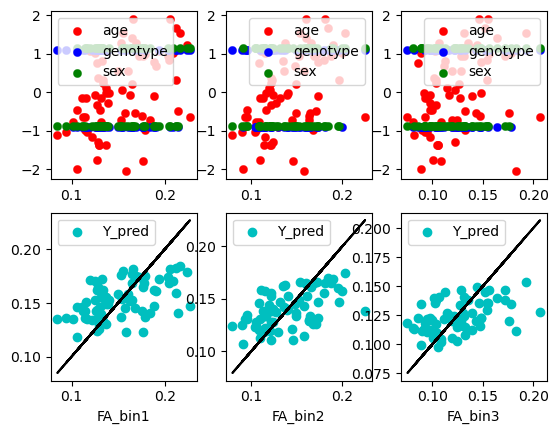

lh_BA1_exvivo
Weights:
[[0.01560946 0.00353745 0.00054763]
 [0.01467462 0.00454359 0.00121848]
 [0.01079593 0.00505374 0.00151799]]
MSE:
0.000654266346765427
R2:
0.23452895079509573


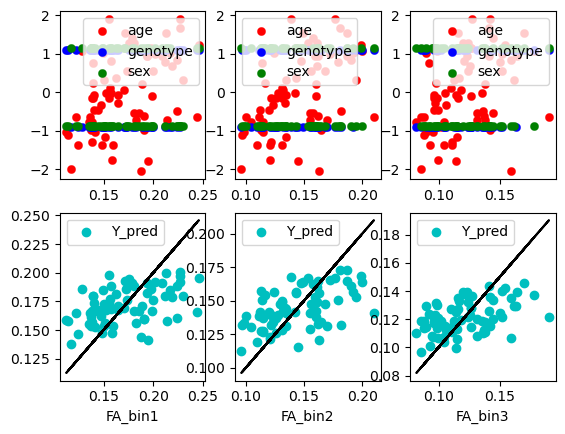

lh_BA2_exvivo_thresh
Weights:
[[ 0.01635893  0.0036902  -0.00642439]
 [ 0.01604073  0.00652208 -0.00312693]
 [ 0.01159738  0.00624006 -0.00338086]]
MSE:
0.000992603219057442
R2:
0.21586520425044894


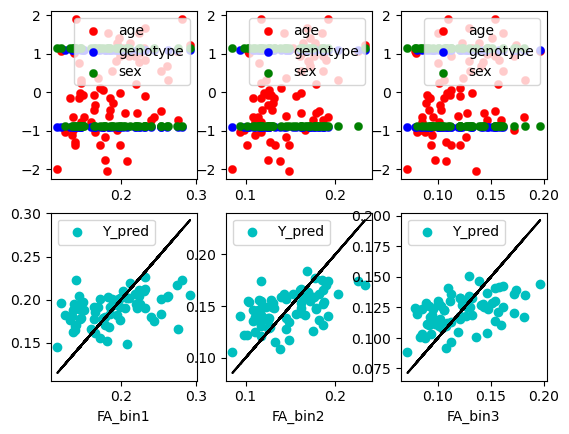

lh_BA2_exvivo
Weights:
[[ 0.0136882   0.00281766 -0.00117163]
 [ 0.01338518  0.00408149 -0.0005471 ]
 [ 0.00920029  0.00439382 -0.00042352]]
MSE:
0.0005896005558993051
R2:
0.21112844986081702


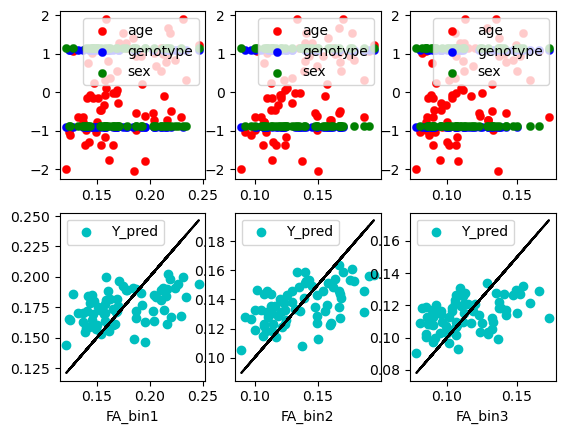

lh_BA3a_exvivo_thresh
Weights:
[[ 0.01447444  0.00461267  0.00365929]
 [ 0.01426067  0.00416488  0.0024154 ]
 [ 0.00866391  0.00411757 -0.00102356]]
MSE:
0.00033424804159317204
R2:
0.33224657334928775


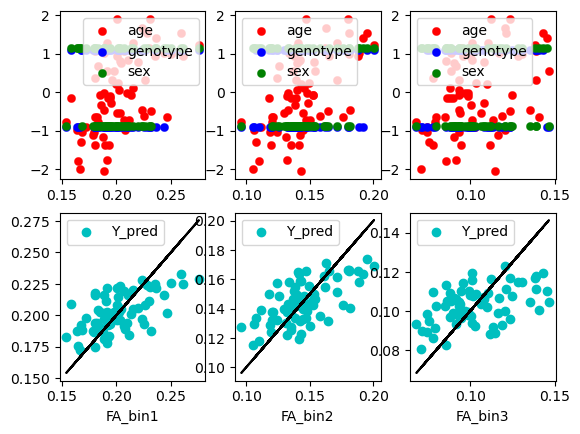

lh_BA3a_exvivo
Weights:
[[ 0.01269348  0.00168827  0.00480724]
 [ 0.01370865  0.00194241  0.00275755]
 [ 0.00922235  0.00282427 -0.00033699]]
MSE:
0.0003302097877687209
R2:
0.3132998379818955


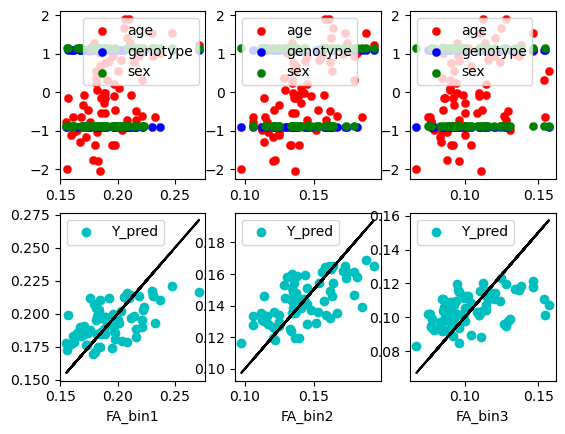

lh_BA3b_exvivo_thresh
Weights:
[[ 1.46814024e-02 -1.86945265e-03  1.43957167e-02]
 [ 1.43571806e-02 -1.77047894e-03  1.10474935e-02]
 [ 1.02704531e-02 -5.87219456e-05  6.75212102e-03]]
MSE:
0.0004981136957742012
R2:
0.3667428141446539


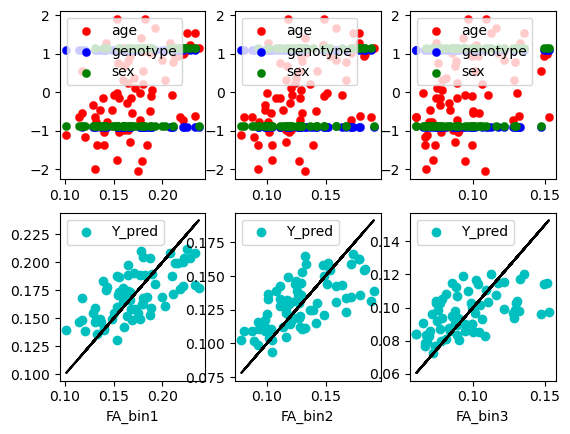

lh_BA3b_exvivo
Weights:
[[0.01322346 0.00050092 0.00698581]
 [0.01349365 0.00112028 0.00555604]
 [0.00971681 0.00251946 0.00397496]]
MSE:
0.0003808456588009232
R2:
0.3153502422190973


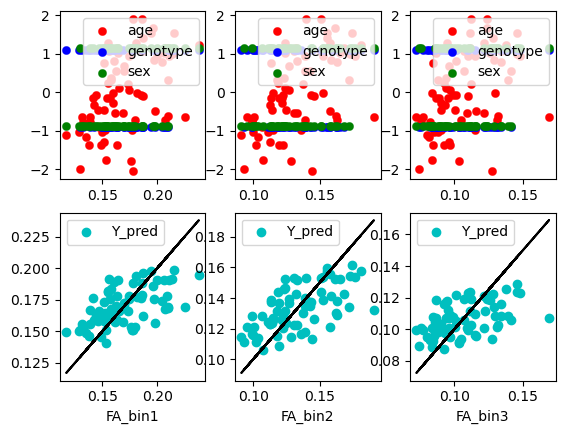

lh_BA4a_exvivo_thresh
Weights:
[[ 0.01370528  0.00129622 -0.00398305]
 [ 0.01505443  0.0019228  -0.00296811]
 [ 0.01054523  0.00299729 -0.004548  ]]
MSE:
0.0007018815560075776
R2:
0.2168408376597273


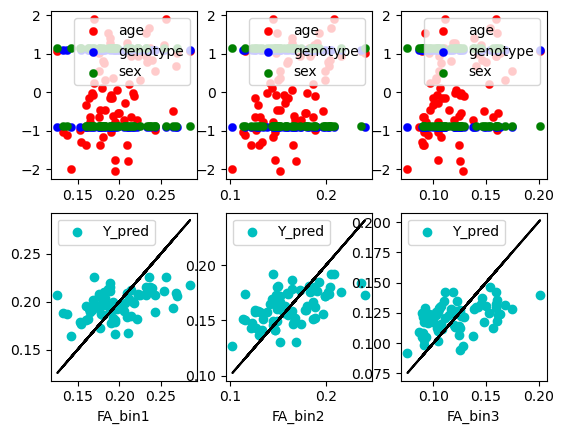

lh_BA4a_exvivo
Weights:
[[ 0.01451688  0.00219057 -0.00205722]
 [ 0.01570279  0.00221687 -0.00202561]
 [ 0.01184626  0.00341363 -0.00232402]]
MSE:
0.0006236273497900229
R2:
0.24910226960714843


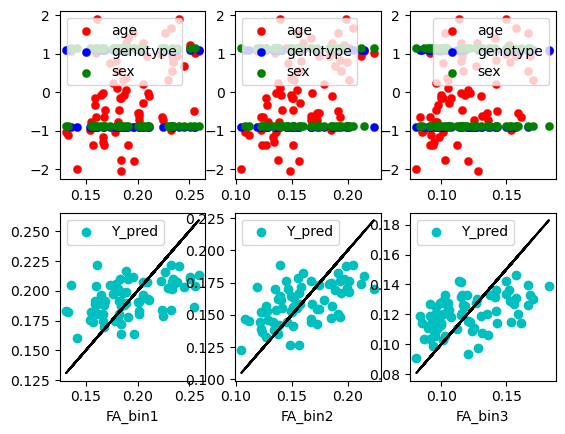

lh_BA4p_exvivo_thresh
Weights:
[[ 0.01133909  0.00335759 -0.00082661]
 [ 0.01424272  0.00446476 -0.00305418]
 [ 0.01013693  0.00437291 -0.00605482]]
MSE:
0.000827056978961786
R2:
0.17314140153182156


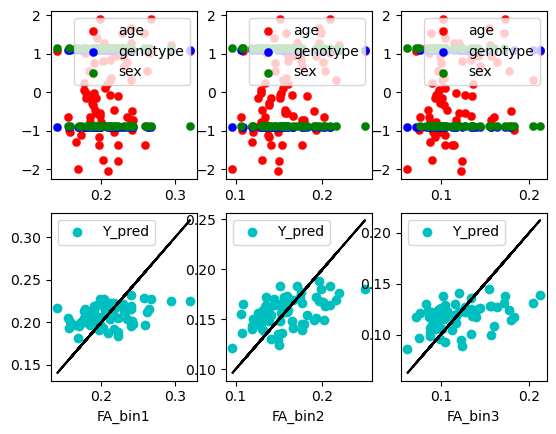

lh_BA4p_exvivo
Weights:
[[ 0.01362221  0.00396131 -0.00272821]
 [ 0.01508823  0.0043452  -0.00283653]
 [ 0.01064058  0.00448564 -0.00509381]]
MSE:
0.0006048410700608351
R2:
0.2507697484794121


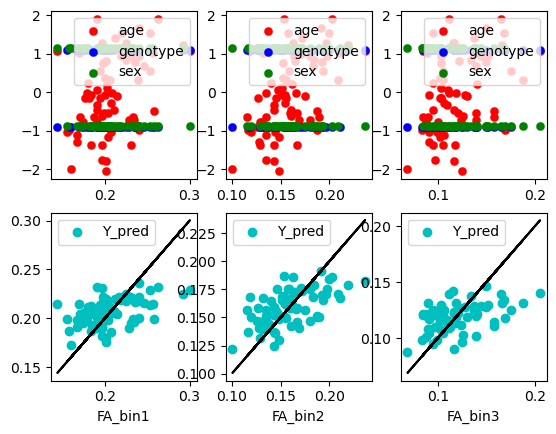

lh_BA6_exvivo_thresh
Weights:
[[ 0.01384053  0.00324838  0.00069769]
 [ 0.01536178  0.0029142  -0.00062155]
 [ 0.01090911  0.00378832  0.0001151 ]]
MSE:
0.0005142672893808343
R2:
0.2614093725812387


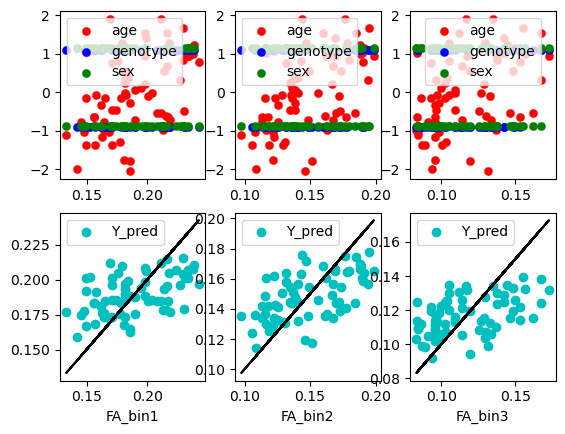

lh_BA6_exvivo
Weights:
[[ 0.01237494  0.00255409  0.00025293]
 [ 0.01423896  0.00269257 -0.00053163]
 [ 0.01001331  0.00342205  0.00012354]]
MSE:
0.0004522944637644282
R2:
0.251897199240153


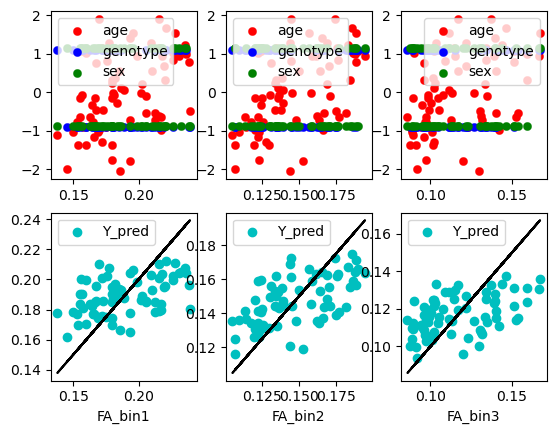

lh_BA44_exvivo_thresh
Weights:
[[0.00735876 0.00054861 0.00056368]
 [0.01157712 0.00193858 0.00256262]
 [0.00881116 0.0017284  0.00466338]]
MSE:
0.0006522712598165526
R2:
0.1270656752617004


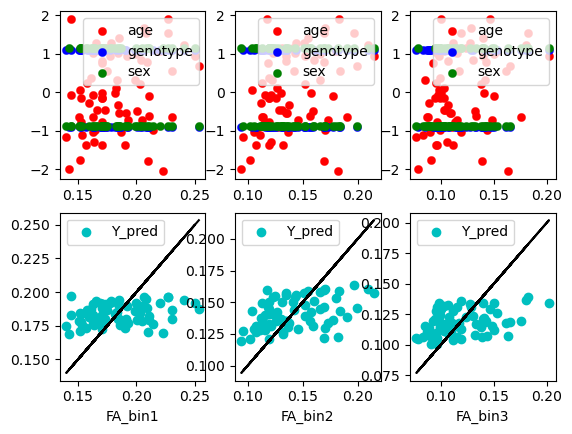

lh_BA44_exvivo
Weights:
[[0.00739928 0.00134441 0.00128756]
 [0.01120138 0.00241943 0.00186355]
 [0.00789001 0.00239323 0.00322302]]
MSE:
0.0005353403235828474
R2:
0.13706665614139127


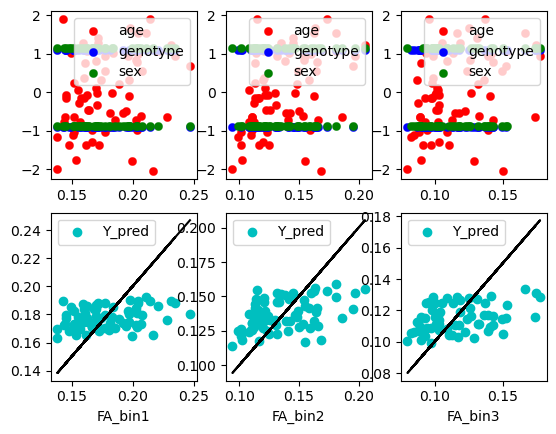

lh_BA45_exvivo_thresh
Weights:
[[0.00716677 0.00320402 0.0007766 ]
 [0.01300569 0.00376908 0.00162294]
 [0.00961734 0.00198594 0.00282588]]
MSE:
0.0009459094080075335
R2:
0.10695403103888779


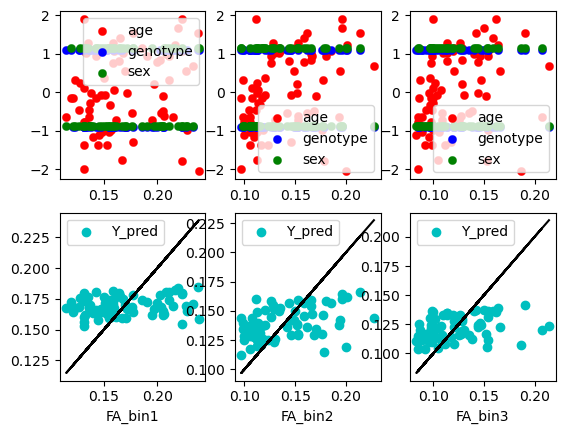

lh_BA45_exvivo
Weights:
[[0.0069639  0.00214843 0.00076262]
 [0.01241677 0.00328294 0.00153605]
 [0.00964935 0.00240882 0.00230756]]
MSE:
0.0007758674244838996
R2:
0.11700321444857276


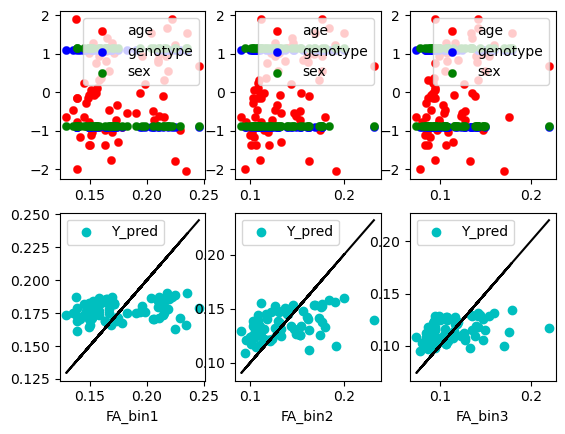

lh_cortex
Weights:
[[ 0.0067073   0.00226642 -0.00070119]
 [ 0.00792324  0.00263401 -0.0013561 ]
 [ 0.00480728  0.00291999 -0.00114629]]
MSE:
0.0004620967927479007
R2:
0.09580582906228063


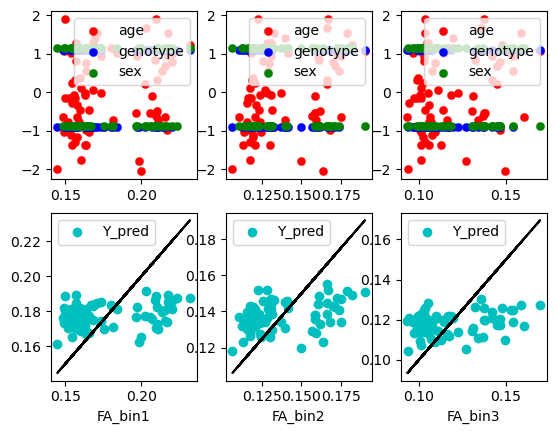

lh_cortex+hipamyg
Weights:
[[ 0.00648804  0.00230188 -0.00076155]
 [ 0.0076071   0.00266295 -0.00144374]
 [ 0.00450091  0.0029424  -0.0012585 ]]
MSE:
0.0004616603561481906
R2:
0.09033198954844857


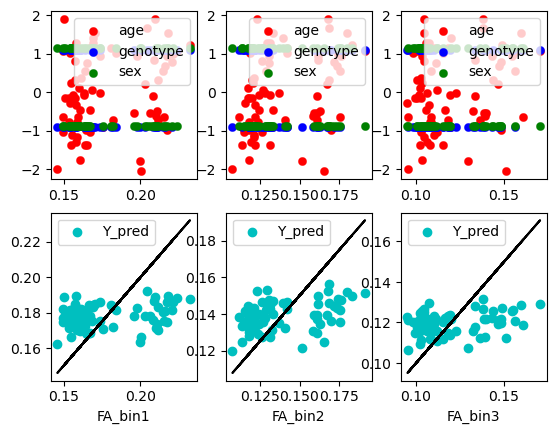

lh_entorhinal_exvivo_thresh
Weights:
[[ 0.00626495  0.00866159 -0.00323759]
 [ 0.00265888  0.00834619 -0.00204829]
 [-0.00154266  0.00729711 -0.00172425]]
MSE:
0.0018951435432288726
R2:
0.04529716429512676


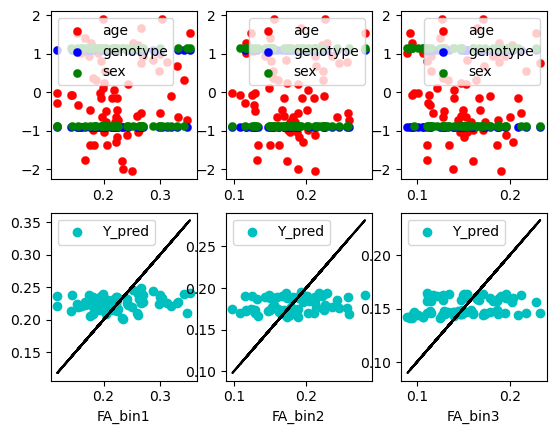

lh_entorhinal_exvivo
Weights:
[[ 0.00294059  0.00917423 -0.00167395]
 [ 0.00119319  0.00826456 -0.00198963]
 [-0.00052399  0.00575095 -0.00113193]]
MSE:
0.0014110741909804205
R2:
0.04702334166856326


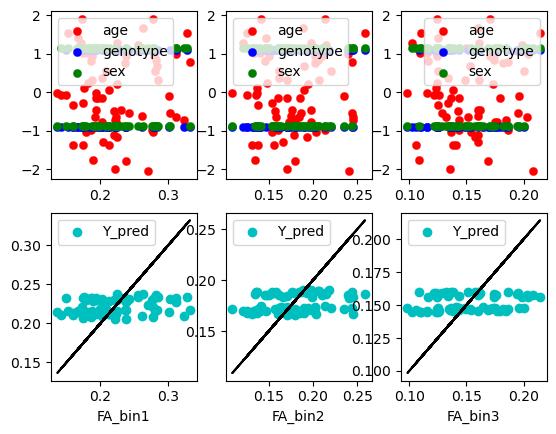

lh_FG1_mpm_vpnl
Weights:
[[ 4.54294454e-03 -1.37802483e-03 -4.34424681e-03]
 [ 2.01611005e-03 -2.84384213e-04 -4.57845031e-03]
 [-1.27664976e-03  2.94081117e-06 -3.53096226e-03]]
MSE:
0.000906541051669525
R2:
0.028297873168826853


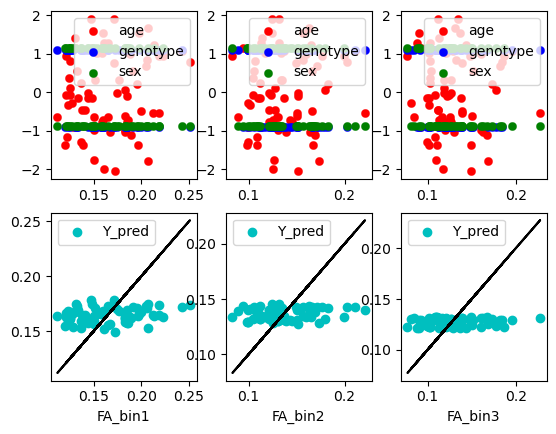

lh_FG2_mpm_vpnl
Weights:
[[ 0.00335064  0.00027951 -0.00822382]
 [ 0.00265491  0.0008105  -0.00809585]
 [-0.0003655   0.00204121 -0.00702796]]
MSE:
0.0012388122711256221
R2:
0.05416122645794393


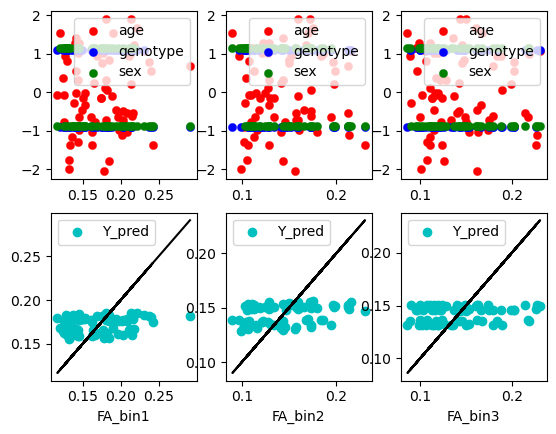

lh_FG3_mpm_vpnl
Weights:
[[ 0.00679238  0.00421131 -0.00335013]
 [ 0.0054116   0.00363872 -0.00492647]
 [ 0.00022925  0.00178862 -0.00401012]]
MSE:
0.0006438843266967378
R2:
0.07110733360179929


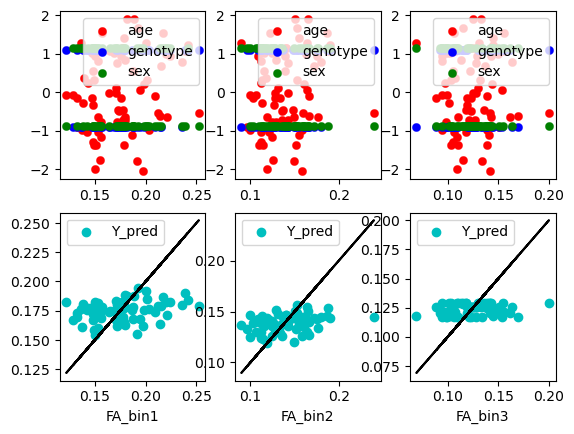

lh_FG4_mpm_vpnl
Weights:
[[ 0.00190162  0.00340408 -0.00189076]
 [ 0.00286981  0.00308103 -0.00254316]
 [-0.00073699  0.00351754 -0.00320108]]
MSE:
0.0005103379233121957
R2:
0.043704226406517575


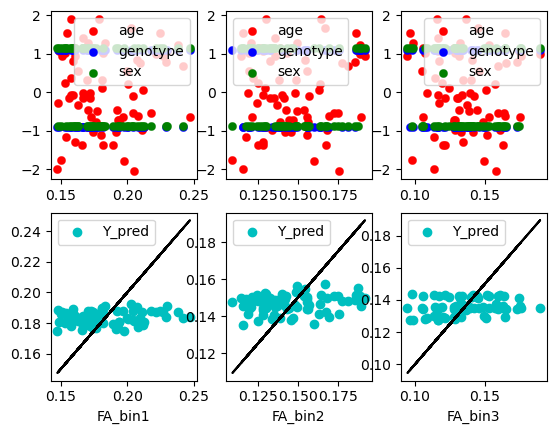

lh_hOc1_mpm_vpnl
Weights:
[[ 0.00899305  0.0020413   0.00180152]
 [ 0.00760367  0.00174091  0.00030897]
 [ 0.00431635  0.00109478 -0.00136318]]
MSE:
0.0006582532823855931
R2:
0.0719070322977476


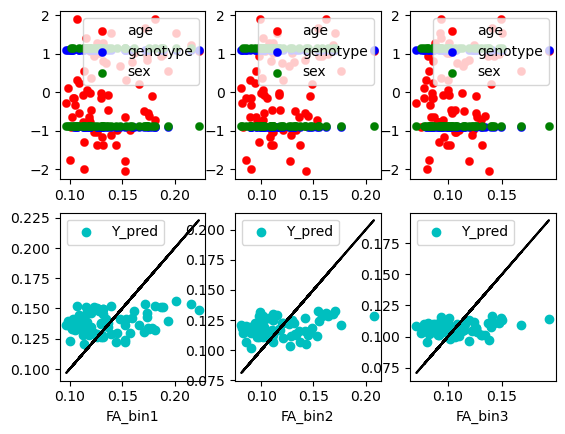

lh_hOc2_mpm_vpnl
Weights:
[[ 0.00965758  0.00268554 -0.00292174]
 [ 0.00806965  0.00258667 -0.00534819]
 [ 0.00356605  0.00255546 -0.00731904]]
MSE:
0.0008046165930904081
R2:
0.10242884338068396


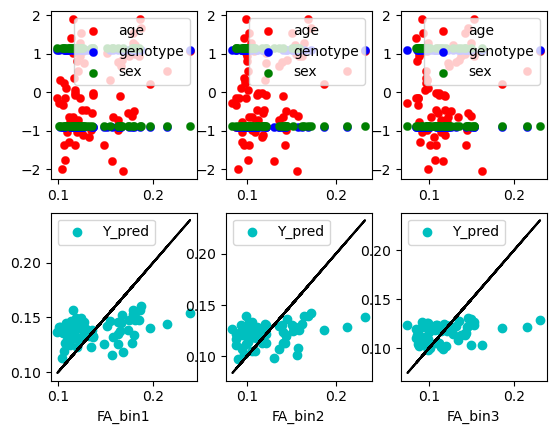

lh_hOc3v_mpm_vpnl
Weights:
[[ 0.0067455   0.00116303 -0.0013928 ]
 [ 0.00597021  0.00169506 -0.00182615]
 [ 0.00257052  0.0017347  -0.00247858]]
MSE:
0.0011009940113876153
R2:
0.029565088442990512


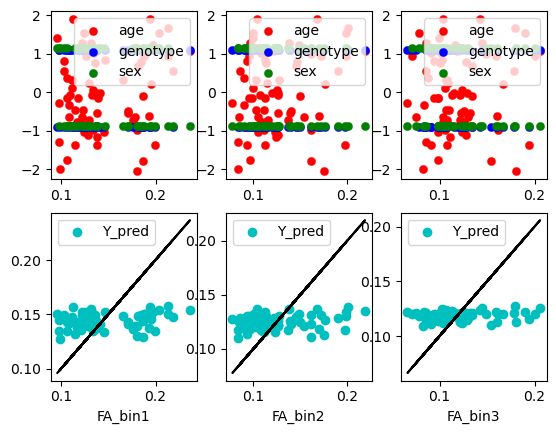

lh_hOc4v_mpm_vpnl
Weights:
[[ 0.00556823  0.00133464 -0.00379748]
 [ 0.00501703  0.00250756 -0.00399416]
 [ 0.00161116  0.00256158 -0.00228165]]
MSE:
0.0010247963706358542
R2:
0.03305174848937883


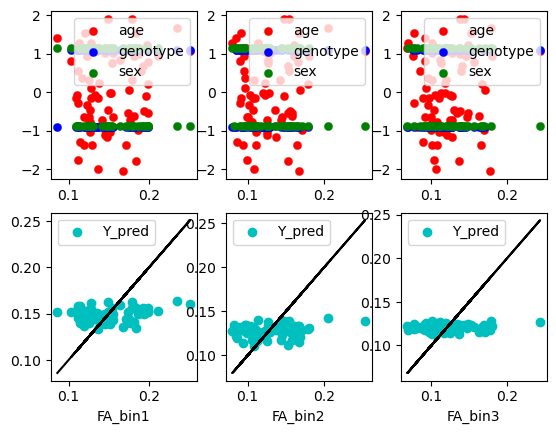

lh_MT_exvivo_thresh
Weights:
[[ 0.00467164 -0.00282549 -0.00513551]
 [ 0.00779032  0.00061002 -0.00471967]
 [ 0.0051205   0.00228289 -0.00342043]]
MSE:
0.0009815835884119332
R2:
0.058242175185875746


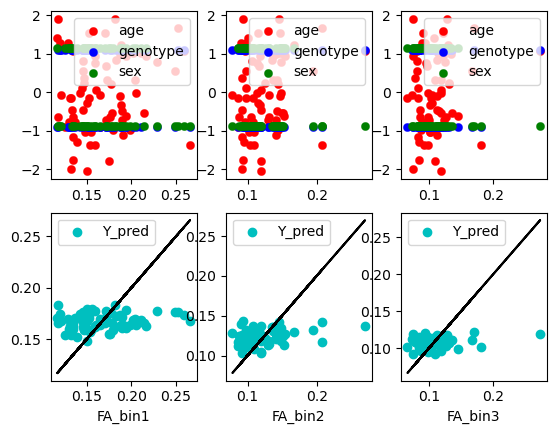

lh_MT_exvivo
Weights:
[[ 0.00121786 -0.00272425 -0.00403339]
 [ 0.00435909  0.0003042  -0.00442221]
 [ 0.00219609  0.00177867 -0.00358373]]
MSE:
0.0008182252935975197
R2:
0.03406780116720972


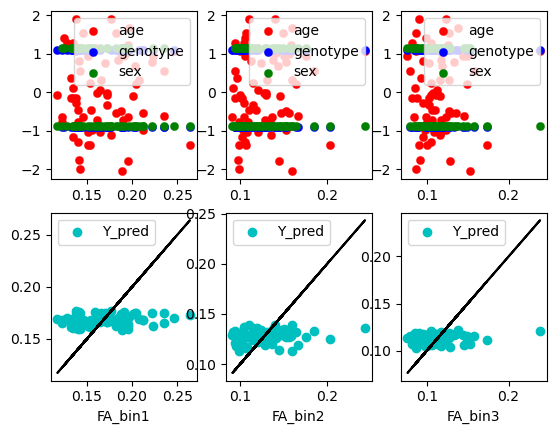

lh_nofix_cortex
Weights:
[[ 0.00601758  0.00221976 -0.00095684]
 [ 0.00720127  0.00257186 -0.0016407 ]
 [ 0.00429359  0.0028277  -0.0015001 ]]
MSE:
0.00046275268840254057
R2:
0.08301180566507775


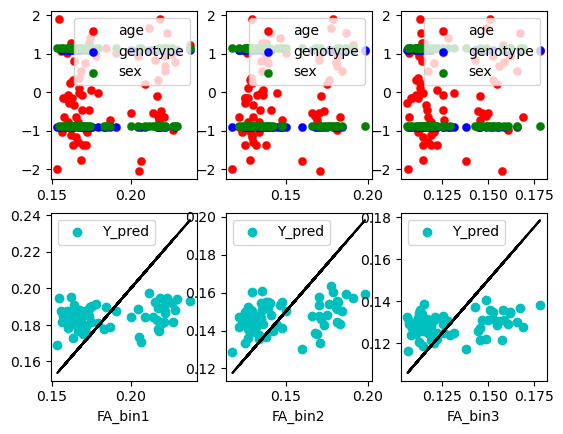

lh_perirhinal_exvivo_thresh
Weights:
[[-0.00035361  0.00996924 -0.00114235]
 [ 0.00162178  0.00677094 -0.0033465 ]
 [ 0.00235509  0.00518731 -0.00360775]]
MSE:
0.001704957436799474
R2:
0.039199087302402846


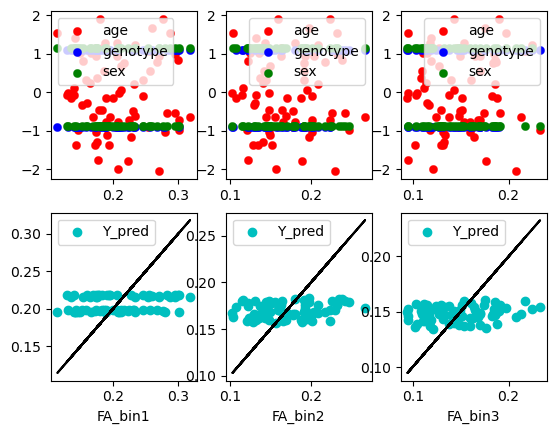

lh_perirhinal_exvivo
Weights:
[[ 0.00079595  0.00975311 -0.00312168]
 [ 0.00192072  0.0083011  -0.00263559]
 [ 0.00183053  0.00641607 -0.00198087]]
MSE:
0.0012909587728708075
R2:
0.05724060248995988


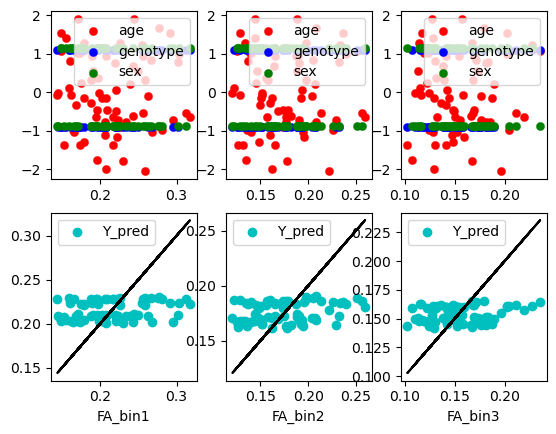

lh_V1_exvivo_thresh
Weights:
[[ 0.00898508  0.00232086  0.00232572]
 [ 0.00735176  0.00202418  0.00084843]
 [ 0.00395475  0.0013618  -0.00079922]]
MSE:
0.0006802569486709293
R2:
0.06726728453856586


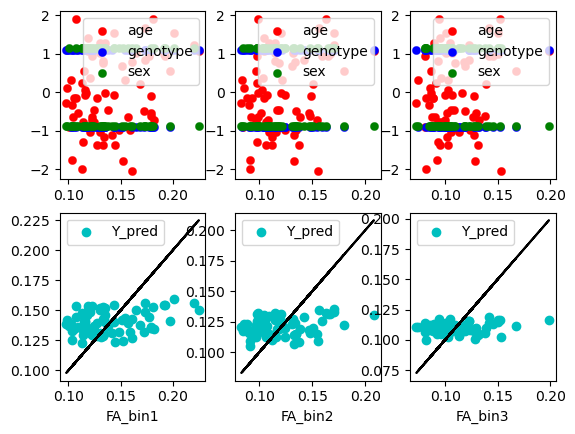

lh_V1_exvivo
Weights:
[[ 0.0097192   0.00257752  0.00101483]
 [ 0.00794606  0.00233341 -0.00118422]
 [ 0.00412517  0.00182863 -0.00312793]]
MSE:
0.000713654770276373
R2:
0.07867219455268333


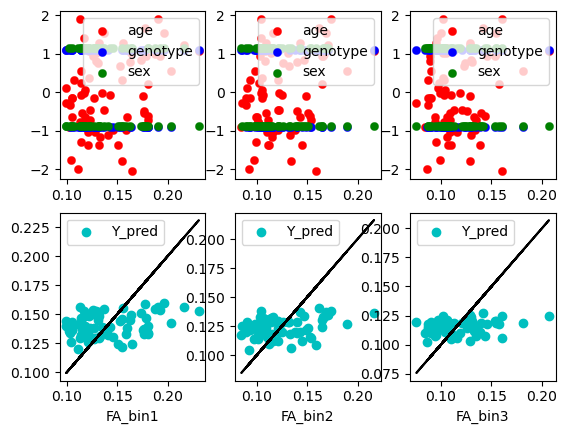

lh_V2_exvivo_thresh
Weights:
[[ 0.00892966  0.00172872 -0.00275562]
 [ 0.00737065  0.00167364 -0.00537477]
 [ 0.00360715  0.00157368 -0.00724693]]
MSE:
0.000875008854956416
R2:
0.08407223359744105


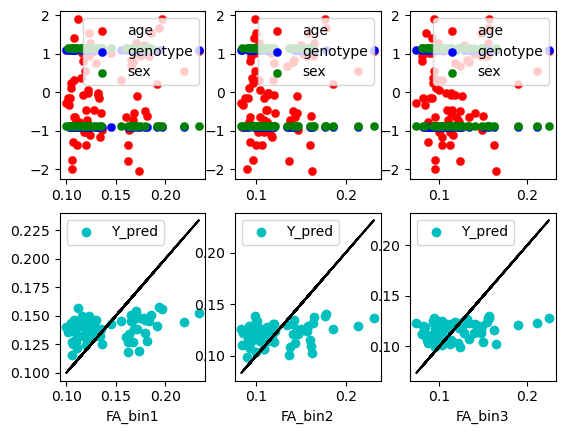

lh_V2_exvivo
Weights:
[[ 0.00808948  0.00184872 -0.00174506]
 [ 0.00684546  0.00210068 -0.0034391 ]
 [ 0.00289303  0.00203079 -0.00465457]]
MSE:
0.0007344968205066874
R2:
0.06851332210451411


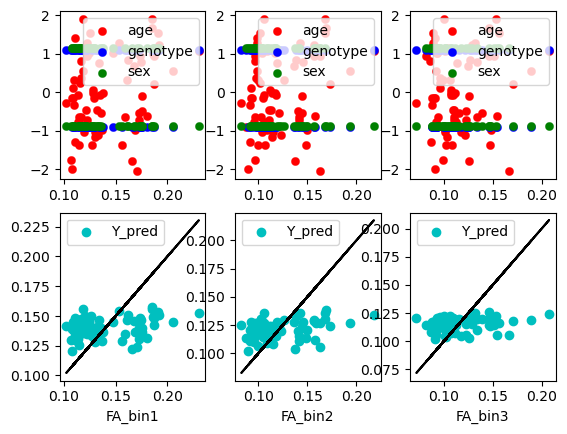

In [36]:
from sklearn.metrics import r2_score
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y = left_dic[region]
    linear_model = LinearRegression()
    linear_model.fit(X, Y)
    r2 = linear_model.score(X, Y)
    weights = linear_model.coef_
    Y_pred = linear_model.predict(X)
    mse = np.mean((Y_pred - Y) ** 2)
    print('Weights:')
    print(weights)
    print('MSE:')
    print(mse)
    print('R2:')
    print(r2)
    plt.subplot(2, 3, 1)
    plt.scatter(Y[:,0], X[:,0], label='age', color='r', linewidths=0.2)
    plt.scatter(Y[:,0], X[:,1], label='genotype', color='b', linewidths=0.2)
    plt.scatter(Y[:,0], X[:,2], label='sex', color='g', linewidths=0.2)
    plt.legend()
    plt.subplot(2, 3, 4)
    plt.scatter(Y[:,0], Y_pred[:,0], label='Y_pred', color='c')
    plt.plot(Y[:,0], Y[:,0], color='k')
    plt.legend()
    plt.xlabel('FA_bin1')
    plt.subplot(2, 3, 2)
    plt.scatter(Y[:,1], X[:,0], label='age', color='r', linewidths=0.2)
    plt.scatter(Y[:,1], X[:,1], label='genotype', color='b', linewidths=0.2)
    plt.scatter(Y[:,1], X[:,2], label='sex', color='g', linewidths=0.2)
    plt.legend()
    plt.subplot(2, 3, 5)
    plt.scatter(Y[:,1], Y_pred[:,1], label='Y_pred', color='c')
    plt.plot(Y[:,1], Y[:,1], color='k')
    plt.legend()
    plt.xlabel('FA_bin2')
    plt.subplot(2, 3, 3)
    plt.scatter(Y[:,2], X[:,0], label='age', color='r', linewidths=0.2)
    plt.scatter(Y[:,2], X[:,1], label='genotype', color='b', linewidths=0.2)
    plt.scatter(Y[:,2], X[:,2], label='sex', color='g', linewidths=0.2)
    plt.legend()
    plt.subplot(2, 3, 6)
    plt.scatter(Y[:,2], Y_pred[:,2], label='Y_pred', color='c')
    plt.plot(Y[:,2], Y[:,2], color='k')
    plt.legend()
    plt.xlabel('FA_bin3')
    plt.show()



In [37]:
# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    age_column = np.append(age_column, age)

age_column = age_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Combine features
X = age_column
print(X)

[[63.        ]
 [20.21      ]
 [37.        ]
 [47.        ]
 [68.        ]
 [44.        ]
 [66.7       ]
 [25.        ]
 [31.        ]
 [60.66      ]
 [54.        ]
 [42.62      ]
 [41.        ]
 [78.13      ]
 [82.        ]
 [56.        ]
 [45.        ]
 [21.        ]
 [31.        ]
 [38.        ]
 [65.41      ]
 [31.        ]
 [42.        ]
 [64.        ]
 [67.        ]
 [61.        ]
 [36.92777778]
 [71.26      ]
 [40.        ]
 [44.        ]
 [76.        ]
 [81.65      ]
 [36.        ]
 [67.86      ]
 [72.        ]
 [55.4       ]
 [44.78      ]
 [76.        ]
 [52.        ]
 [57.        ]
 [41.        ]
 [50.        ]
 [32.        ]
 [34.        ]
 [38.        ]
 [48.        ]
 [64.45      ]
 [53.        ]
 [65.        ]
 [45.        ]
 [42.        ]
 [51.        ]
 [58.        ]
 [50.88      ]
 [57.        ]
 [35.        ]
 [50.        ]
 [42.        ]
 [70.        ]
 [70.        ]
 [36.        ]
 [51.        ]
 [68.        ]
 [72.        ]
 [50.        ]
 [67.04      ]
 [69.     

lh_BA1_exvivo_thresh
Weights:
[[0.00108745]] [[0.00103112]] [[0.00070578]]
MSE:
0.0009027009937903634 0.0007517460917036819 0.0007194095278789527
R2:
0.24016455637997414 0.25442163481937874 0.14314643899016122


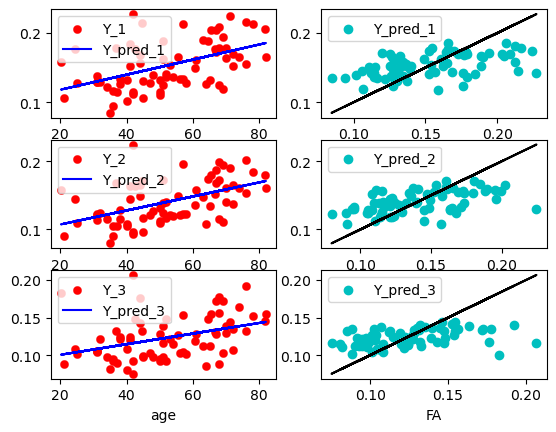

lh_BA1_exvivo
Weights:
[[0.00098056]] [[0.00091326]] [[0.00065996]]
MSE:
0.0009037967259490897 0.0005967367453698268 0.0005223131785029549
R2:
0.20425149528219044 0.2521826916935981 0.1674966739063013


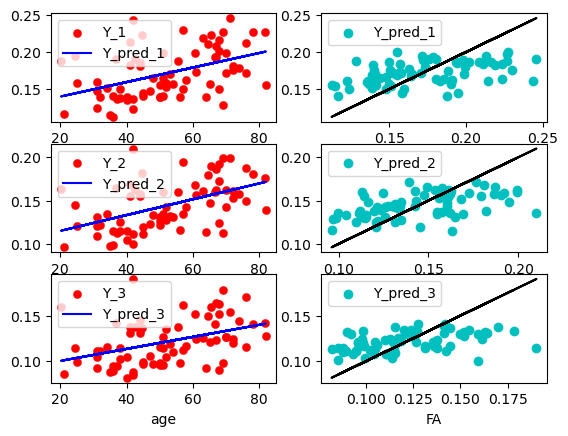

lh_BA2_exvivo_thresh
Weights:
[[0.00103027]] [[0.00098926]] [[0.00070522]]
MSE:
0.0015878449048178723 0.0008233359910448169 0.0007320774737107982
R2:
0.1388889239092318 0.22286818479146886 0.14082557342611346


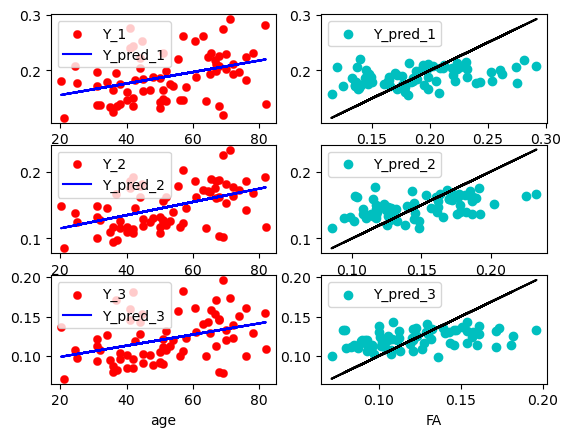

lh_BA2_exvivo
Weights:
[[0.00086241]] [[0.00083404]] [[0.00056244]]
MSE:
0.0008349076856707526 0.0005330055799794042 0.0004471636739154363
R2:
0.1769073724534611 0.23947802610281288 0.14580125646562625


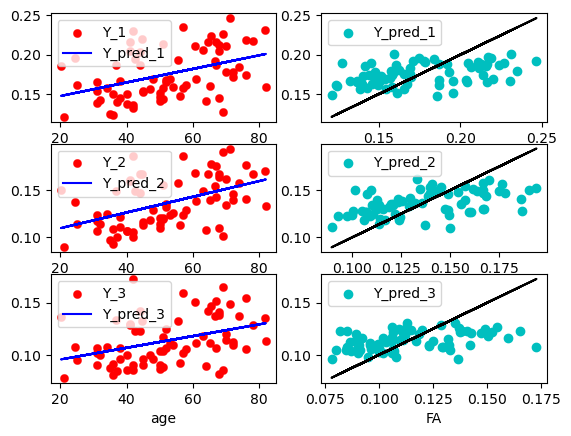

lh_BA3a_exvivo_thresh
Weights:
[[0.00089902]] [[0.00088877]] [[0.00053001]]
MSE:
0.000427595002352297 0.00032733882444095484 0.00031991511948891593
R2:
0.31321540410098136 0.36797929093567827 0.17482321825995994


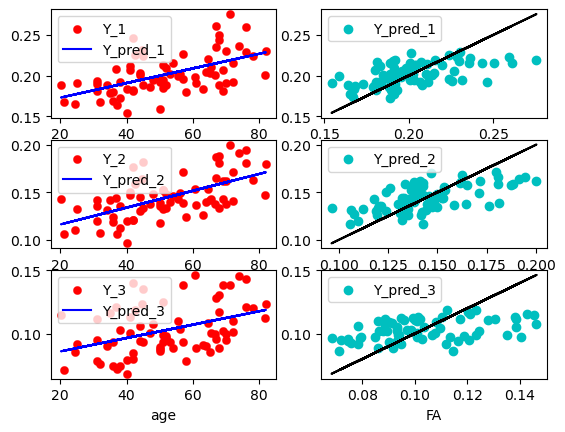

lh_BA3a_exvivo
Weights:
[[0.00080393]] [[0.00086829]] [[0.00057455]]
MSE:
0.000384688690596328 0.00029574312544314573 0.00035374090534591213
R2:
0.2884389987861309 0.3808326317375278 0.18377894854033905


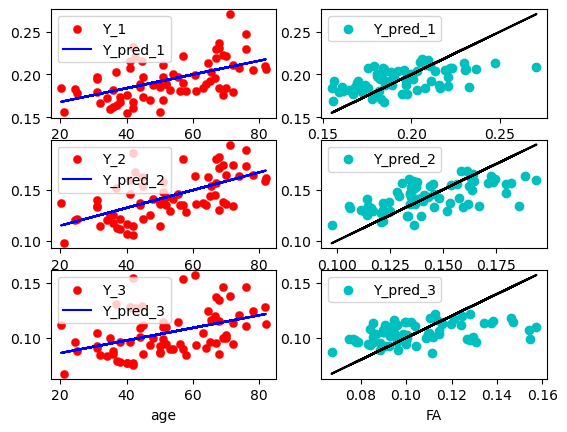

lh_BA3b_exvivo_thresh
Weights:
[[0.00095277]] [[0.00093242]] [[0.00065918]]
MSE:
0.0008314585082493412 0.0006062705004701602 0.0004444652757269745
R2:
0.2084967275754298 0.25705606169385065 0.1908544745331494


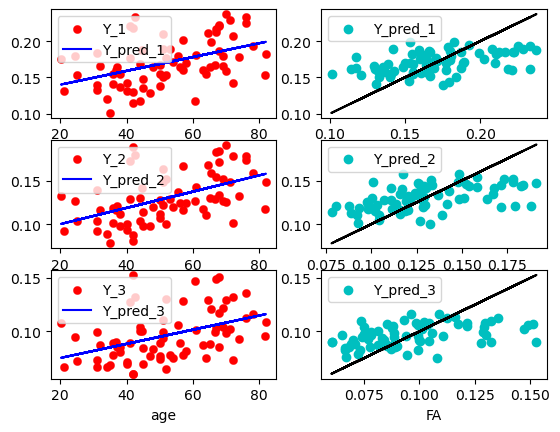

lh_BA3b_exvivo
Weights:
[[0.00084538]] [[0.00085906]] [[0.00060692]]
MSE:
0.0005062120400161774 0.0003846379074262066 0.00035221195045179236
R2:
0.25408216609362355 0.31643459975832855 0.20148836375212964


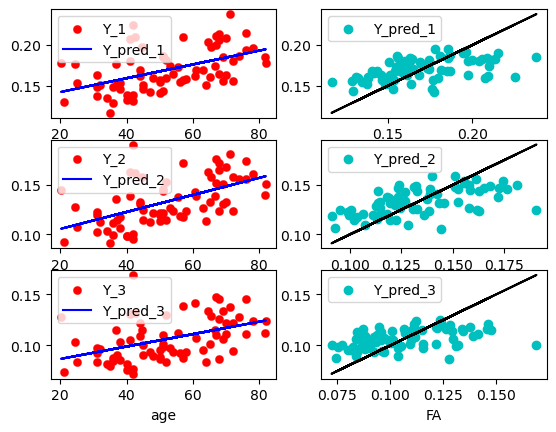

lh_BA4a_exvivo_thresh
Weights:
[[0.00087491]] [[0.00095712]] [[0.00066005]]
MSE:
0.0009475891905558805 0.000633862577135246 0.000587111945098585
R2:
0.16311169333417475 0.25854467502378364 0.15185125849384362


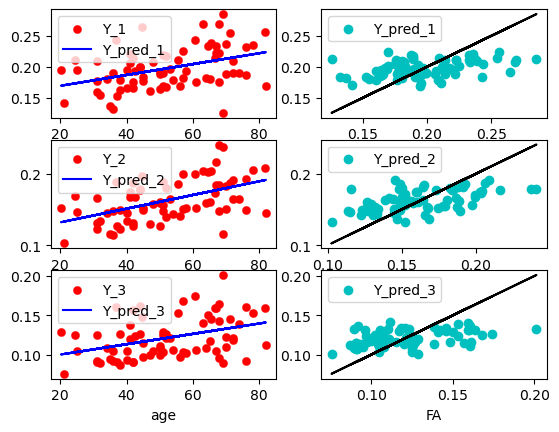

lh_BA4a_exvivo
Weights:
[[0.00092036]] [[0.00099651]] [[0.00074017]]
MSE:
0.0008181819465001694 0.0005720804216496164 0.0005178044315359638
R2:
0.19986551478733838 0.29518616553195653 0.20336066511840234


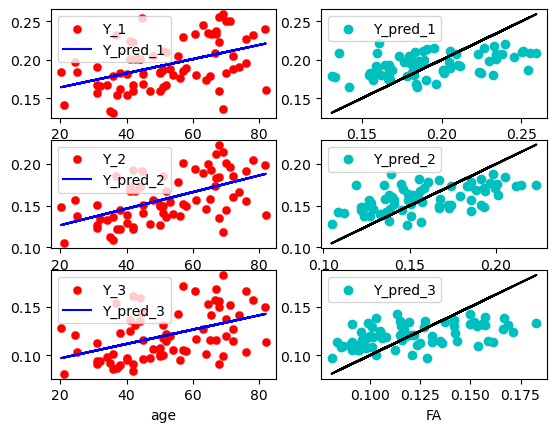

lh_BA4p_exvivo_thresh
Weights:
[[0.00070736]] [[0.00088753]] [[0.00062491]]
MSE:
0.0009460098995834258 0.0007169814392321826 0.0009204991835702953
R2:
0.11317160080427535 0.20953374974343075 0.09285404567284727


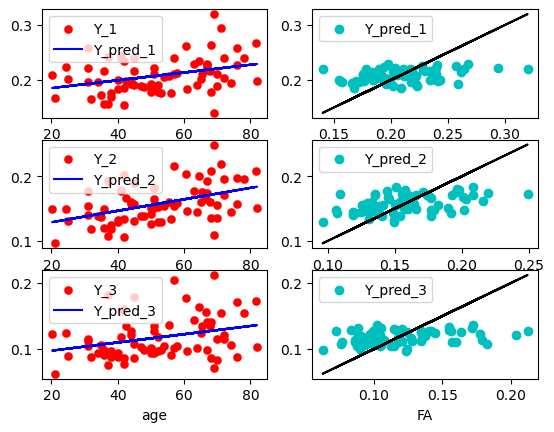

lh_BA4p_exvivo
Weights:
[[0.00085091]] [[0.0009427]] [[0.00065622]]
MSE:
0.0007574460401750706 0.0005079225400696739 0.000650977434328122
R2:
0.1874103395348442 0.2968377997528968 0.13763665647854328


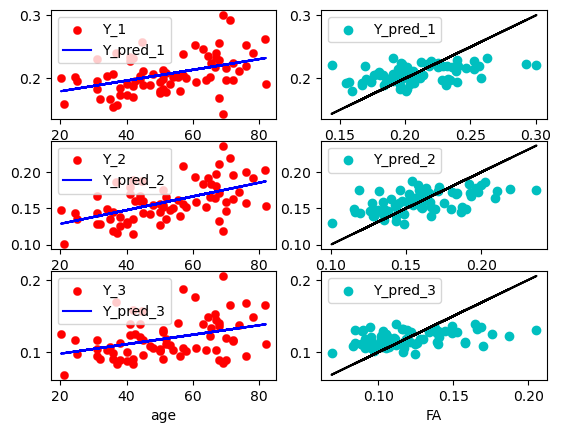

lh_BA6_exvivo_thresh
Weights:
[[0.0008686]] [[0.00096929]] [[0.0006764]]
MSE:
0.0006117279076794486 0.0004915810950839582 0.00047327677864454306
R2:
0.22932974567574582 0.31559947759540474 0.18912729037910936


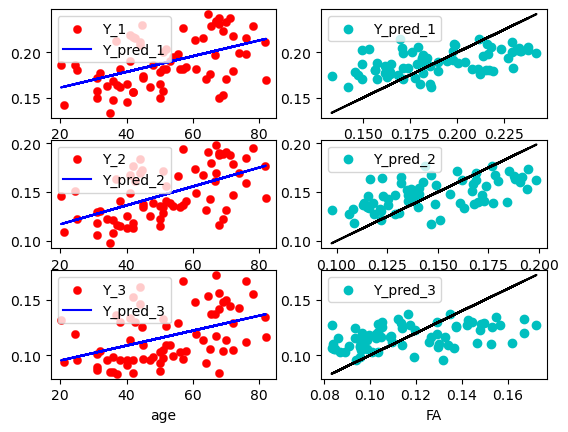

lh_BA6_exvivo
Weights:
[[0.00077915]] [[0.00089849]] [[0.00062123]]
MSE:
0.0005569806672549155 0.00042790613121411946 0.0003976050254166546
R2:
0.2082175320833316 0.3128019921001215 0.189748821940942


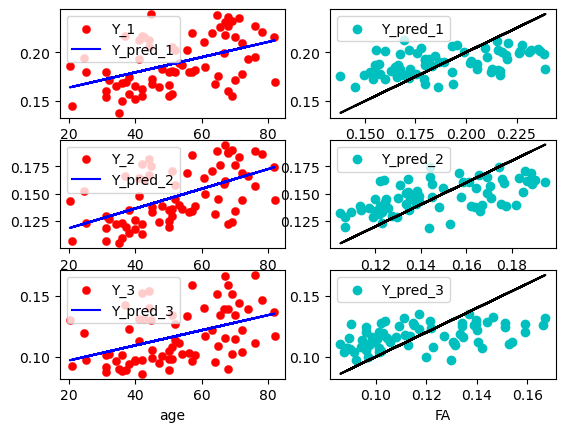

lh_BA44_exvivo_thresh
Weights:
[[0.0004698]] [[0.00073116]] [[0.00055377]]
MSE:
0.0006541528435032574 0.0006737018329060975 0.00066272693584269
R2:
0.07527813481141366 0.16069051116284305 0.10043161887938046


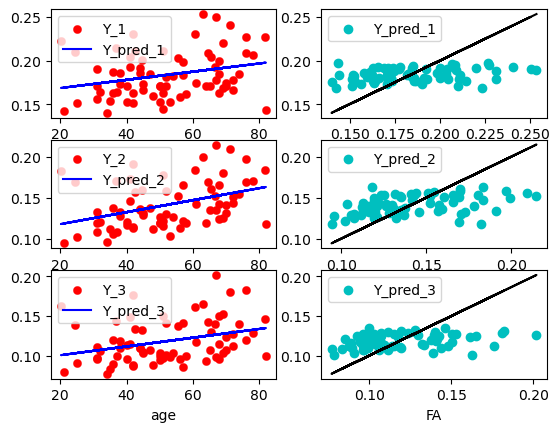

lh_BA44_exvivo
Weights:
[[0.00046671]] [[0.00070394]] [[0.00049044]]
MSE:
0.0005900275980433272 0.0005425360737322592 0.0005002984289171337
R2:
0.08178631835053429 0.18057542256092352 0.10394332328594946


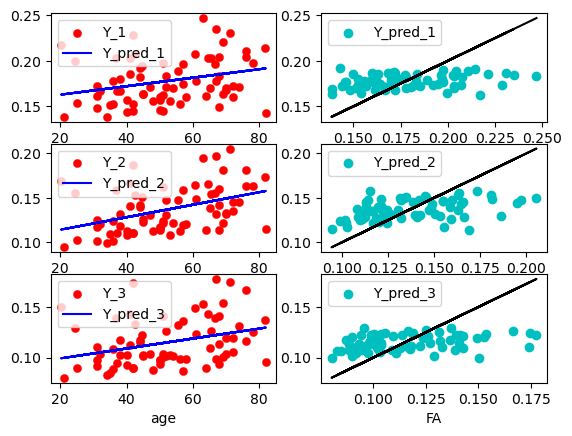

lh_BA45_exvivo_thresh
Weights:
[[0.00043922]] [[0.00081096]] [[0.00060457]]
MSE:
0.0011524291038111343 0.0009161749975201802 0.0008064911360250265
R2:
0.03882156705237494 0.14762673734122744 0.09856935512122744


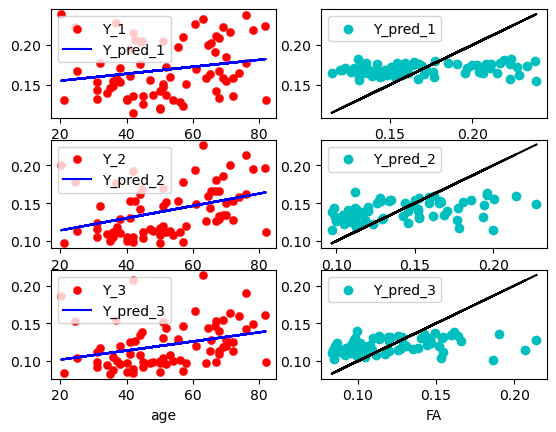

lh_BA45_exvivo
Weights:
[[0.00043338]] [[0.0007764]] [[0.00060393]]
MSE:
0.0008847162528262081 0.0007706733743645403 0.0006997558197196515
R2:
0.04872463032678365 0.15875763802005793 0.11171074475046916


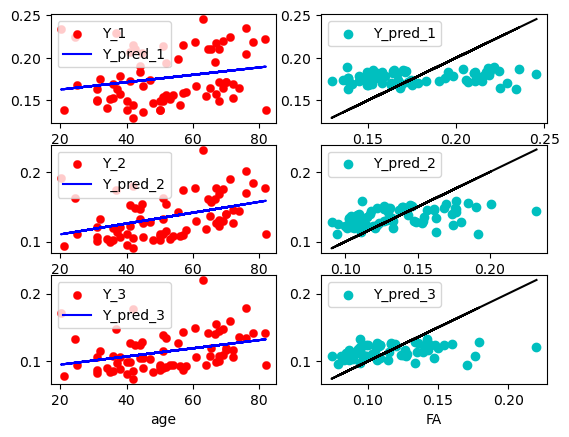

lh_cortex
Weights:
[[0.00041658]] [[0.00049258]] [[0.00028995]]
MSE:
0.0005941113764639369 0.0004406595536773681 0.00037670070885786086
R2:
0.06583591773029374 0.11727280861158829 0.05109670169657121


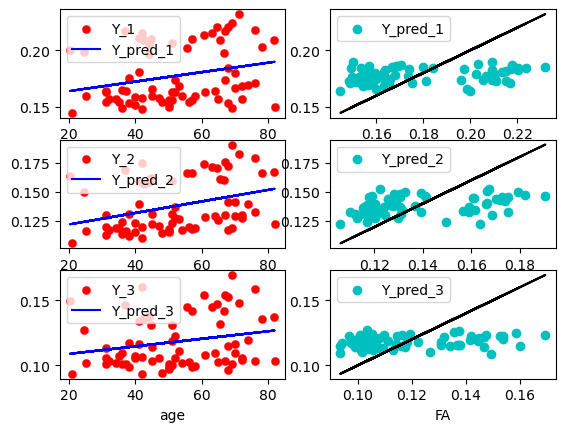

lh_cortex+hipamyg
Weights:
[[0.00040224]] [[0.00047207]] [[0.00027012]]
MSE:
0.0005925702474136373 0.00044098359582675457 0.00037776225247317287
R2:
0.06180753714152609 0.10867504696352426 0.04452618631498095


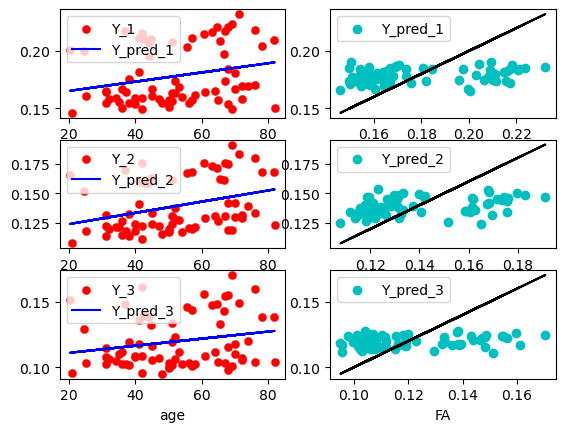

lh_entorhinal_exvivo_thresh
Weights:
[[0.00034533]] [[0.0001149]] [[-0.00014854]]
MSE:
0.0030038955673024684 0.001636266351507658 0.0012665412255039908
R2:
0.009487448552406574 0.0019428858938372873 0.00418570050936018


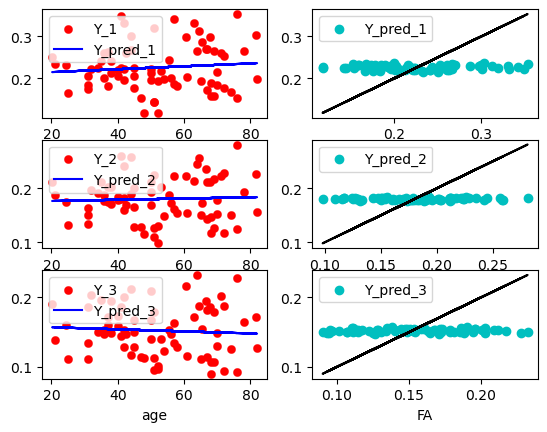

lh_entorhinal_exvivo
Weights:
[[0.00012724]] [[2.10761709e-05]] [[-7.26121126e-05]]
MSE:
0.0023318629302839155 0.0012582380274721613 0.0008398748948027917
R2:
0.0016724784651602764 8.517169348698506e-05 0.001512369435956895


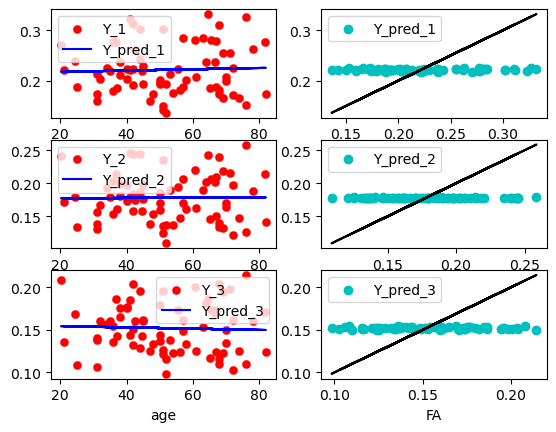

lh_FG1_mpm_vpnl
Weights:
[[0.00030345]] [[0.00013338]] [[-8.09402196e-05]]
MSE:
0.0010207852626931792 0.00088299859764127 0.0008690988028993626
R2:
0.021300366641263113 0.004837827737691702 0.0018154408773579656


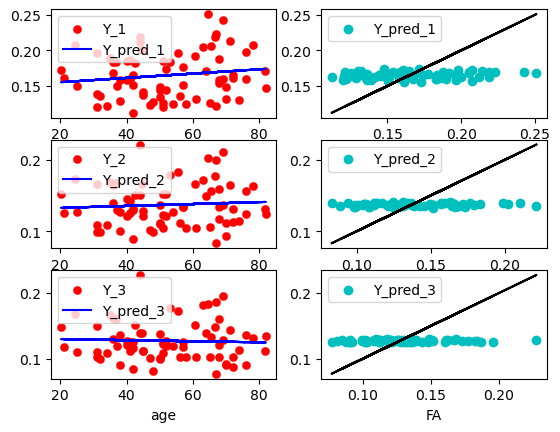

lh_FG2_mpm_vpnl
Weights:
[[0.00021676]] [[0.00016829]] [[-3.49476815e-05]]
MSE:
0.001288326870195123 0.0011657245677272933 0.0014529768678934068
R2:
0.008722299591710558 0.005827957519982219 0.0002027690307202512


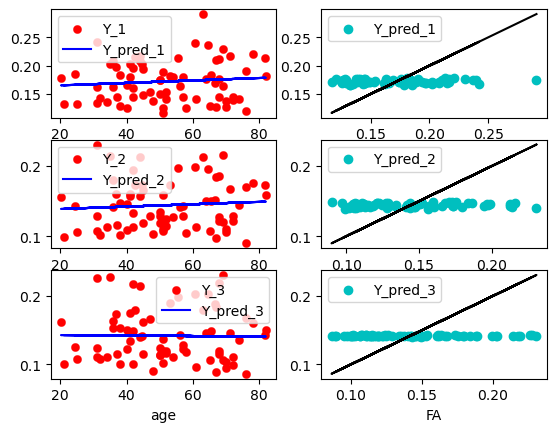

lh_FG3_mpm_vpnl
Weights:
[[0.00040972]] [[0.00032531]] [[3.98245519e-06]]
MSE:
0.0008384710844066604 0.0006894652618954166 0.0004944598504783308
R2:
0.046080485761006096 0.03571059038548696 7.738896851683386e-06


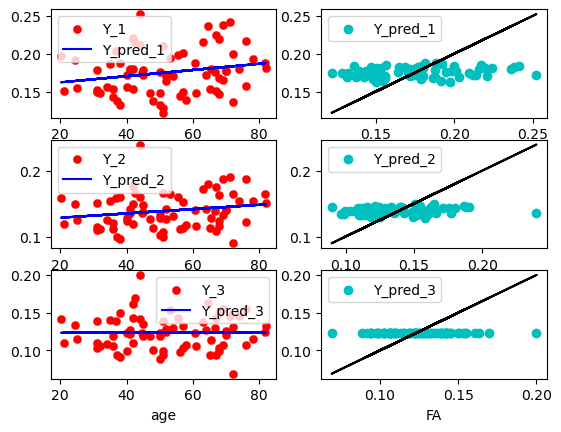

lh_FG4_mpm_vpnl
Weights:
[[9.98507097e-05]] [[0.00016462]] [[-7.03241202e-05]]
MSE:
0.0006481670191358423 0.00048013707204615615 0.00045957937736178255
R2:
0.003697585482984156 0.013435489447544802 0.0025896056238029486


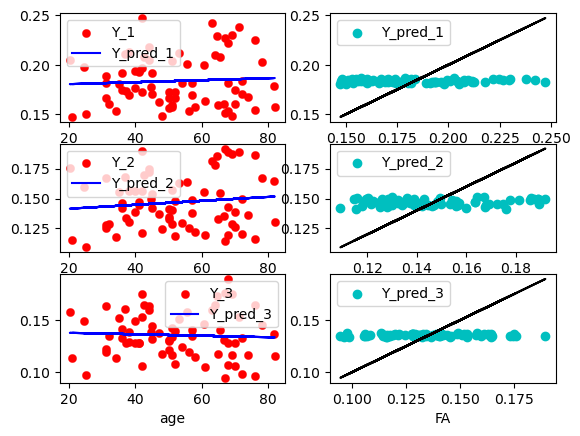

lh_hOc1_mpm_vpnl
Weights:
[[0.00056437]] [[0.00047751]] [[0.00027089]]
MSE:
0.0008157274528958978 0.000633745259654464 0.000538414158719842
R2:
0.08609865817452123 0.07987557271502854 0.031837726200250716


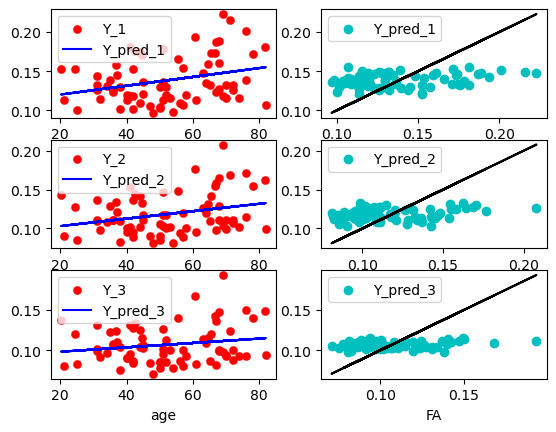

lh_hOc2_mpm_vpnl
Weights:
[[0.00060445]] [[0.00050377]] [[0.00021475]]
MSE:
0.0008701207420907758 0.0008386467983088172 0.0008215328038372558
R2:
0.09199075710575333 0.06804408708458343 0.013363635552440134


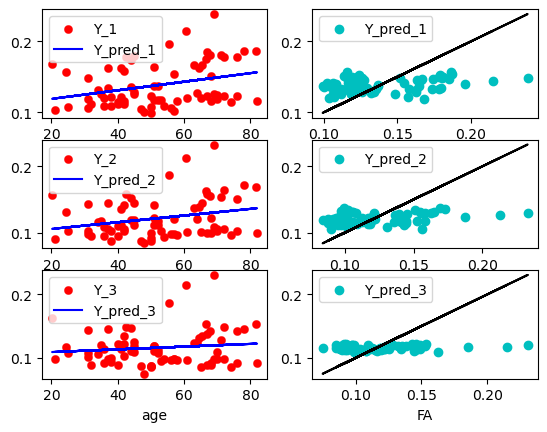

lh_hOc3v_mpm_vpnl
Weights:
[[0.00042682]] [[0.00037343]] [[0.00015453]]
MSE:
0.00122533648149166 0.001077198778543092 0.0010202551906668567
R2:
0.0346297465761044 0.030289030025829167 0.005615320032237303


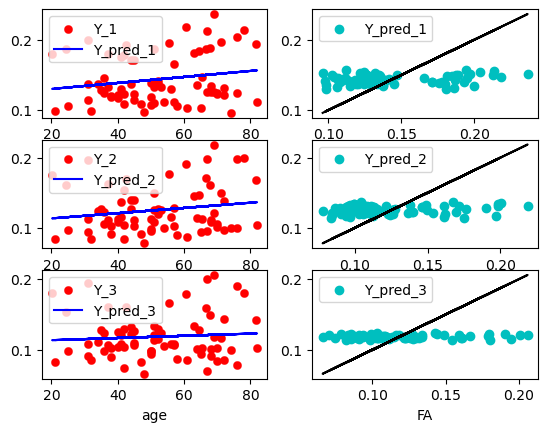

lh_hOc4v_mpm_vpnl
Weights:
[[0.00035073]] [[0.0003073]] [[8.70466796e-05]]
MSE:
0.0011065413157555625 0.0010395515897362768 0.0009812133535820123
R2:
0.026120621081503703 0.021447124207376933 0.0018597056651487032


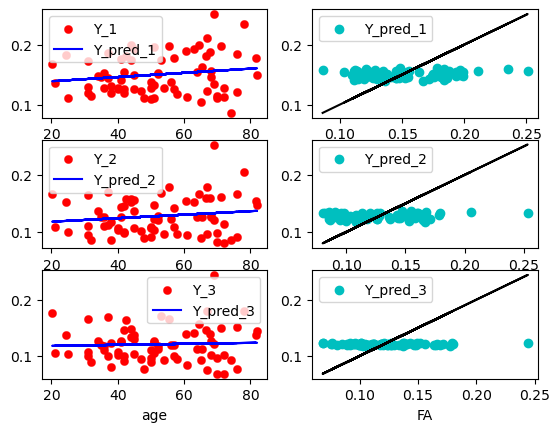

lh_MT_exvivo_thresh
Weights:
[[0.0003219]] [[0.00049906]] [[0.00031529]]
MSE:
0.0011680864244205088 0.0009837051703790853 0.0008661952051406172
R2:
0.020955037919306863 0.05757114111728279 0.026943100828145106


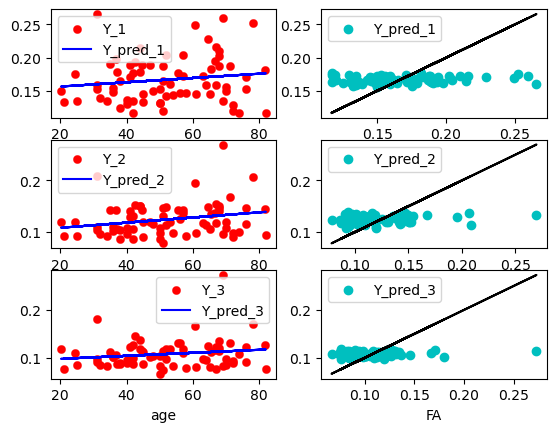

lh_MT_exvivo
Weights:
[[9.84640709e-05]] [[0.00028015]] [[0.00013052]]
MSE:
0.0010625075624157848 0.0008099159875685932 0.0006410270536153739
R2:
0.002196747380428854 0.022845556563971803 0.006371131838806887


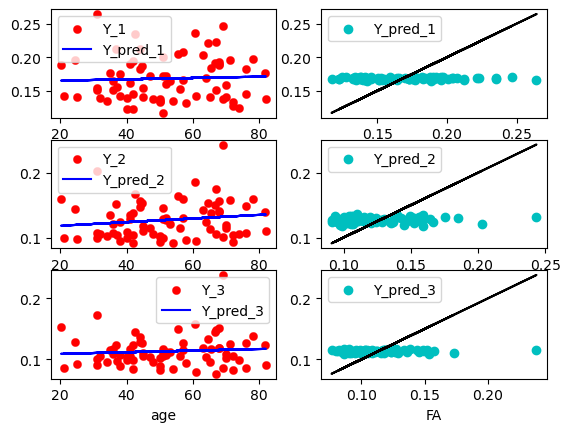

lh_nofix_cortex
Weights:
[[0.00037259]] [[0.00044663]] [[0.00025764]]
MSE:
0.0005948356540088416 0.0004427498572094236 0.00037730045870746926
R2:
0.05330631870541702 0.09804741015972762 0.04071906195577857


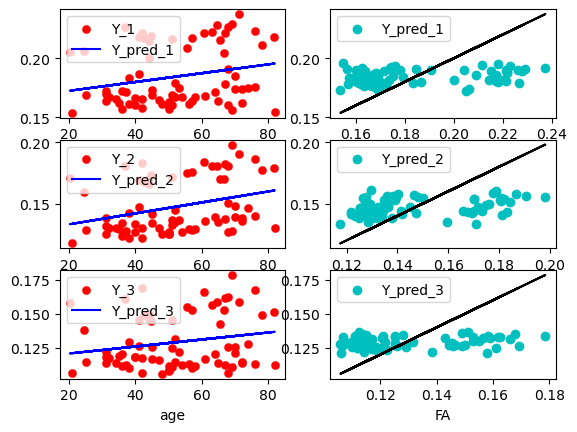

lh_perirhinal_exvivo_thresh
Weights:
[[-9.04544482e-05]] [[5.93590602e-05]] [[0.00011748]]
MSE:
0.0025923193294390464 0.0015768952286412728 0.0011486189547563273
R2:
0.0007609435087443384 0.0005388262917834785 0.0028907588723690036


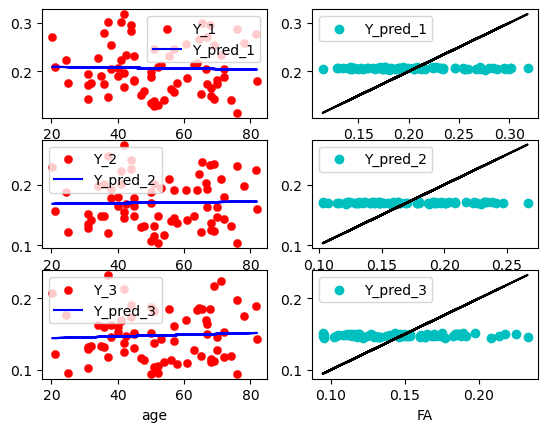

lh_perirhinal_exvivo
Weights:
[[-1.42590337e-05]] [[6.78965648e-05]] [[7.47317746e-05]]
MSE:
0.0019687241223031882 0.0012239317400967956 0.0009126465475434715
R2:
2.4917023629944524e-05 0.0009079367036332053 0.001474276320683865


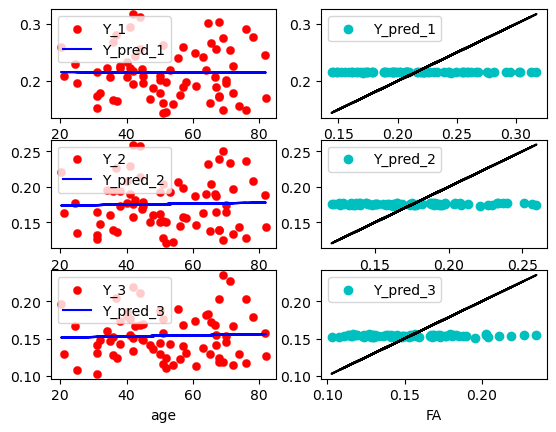

lh_V1_exvivo_thresh
Weights:
[[0.00056176]] [[0.00045917]] [[0.00024559]]
MSE:
0.0008544131395007105 0.000650731567172988 0.0005527770159006343
R2:
0.08182247663683984 0.0725041091182439 0.025650176713509776


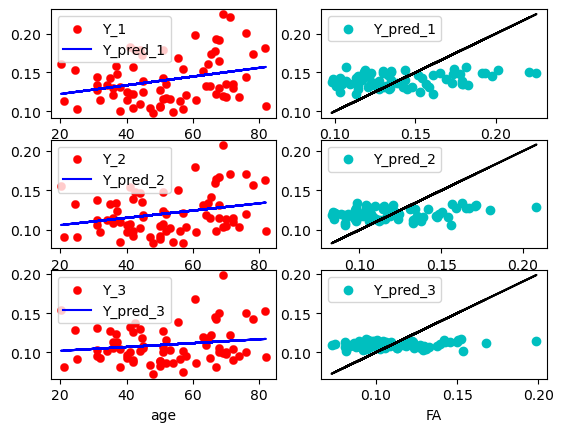

lh_V1_exvivo
Weights:
[[0.00060774]] [[0.00049605]] [[0.00025421]]
MSE:
0.0008711559658032003 0.0006988350966547271 0.0005992527970114946
R2:
0.09280131406739778 0.07830123166185954 0.025358414255812978


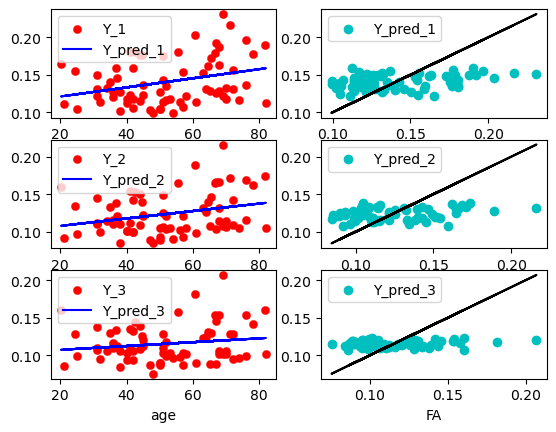

lh_V2_exvivo_thresh
Weights:
[[0.00056406]] [[0.00046501]] [[0.00022408]]
MSE:
0.0009304220096855818 0.0009152027121739911 0.000880024721341334
R2:
0.07621806603915926 0.053932394270939654 0.013579548705349609


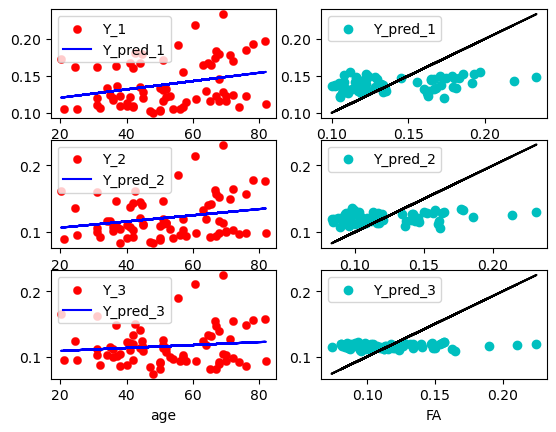

lh_V2_exvivo
Weights:
[[0.00050879]] [[0.00042759]] [[0.00017405]]
MSE:
0.0008195055083175623 0.0007447218723784922 0.0006903510543082012
R2:
0.07081738194206466 0.055921735477299284 0.01047665589243918


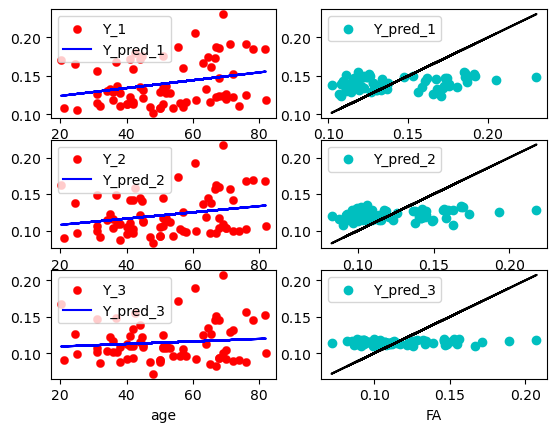

In [41]:
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y_1 = left_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = left_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = left_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    print('Weights:')
    print(weights_1, weights_2, weights_3)
    print('MSE:')
    print(mse_1, mse_2, mse_3)
    print('R2:')
    print(r2_1, r2_2, r2_3)
    plt.subplot(3, 2, 1)
    plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 2)
    plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
    plt.plot(Y_1[:,0], Y_1[:,0], color='k')
    plt.legend()
    plt.xlabel('FA')
    plt.subplot(3, 2, 3)
    plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 4)
    plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
    plt.plot(Y_2[:,0], Y_2[:,0], color='k')
    plt.legend()
    plt.xlabel('FA')
    plt.subplot(3, 2, 5)
    plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 6)
    plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
    plt.plot(Y_3[:,0], Y_3[:,0], color='k')
    plt.legend()
    plt.xlabel('FA')

    plt.show()


rh_BA1_exvivo_thresh
Weights:
[[0.00112862]] [[0.00120153]] [[0.00081379]]
MSE:
0.000903208983051219 0.0007097446874596269 0.0005804346512251562
R2:
0.2538808332329532 0.3292049162468229 0.21586282479322771


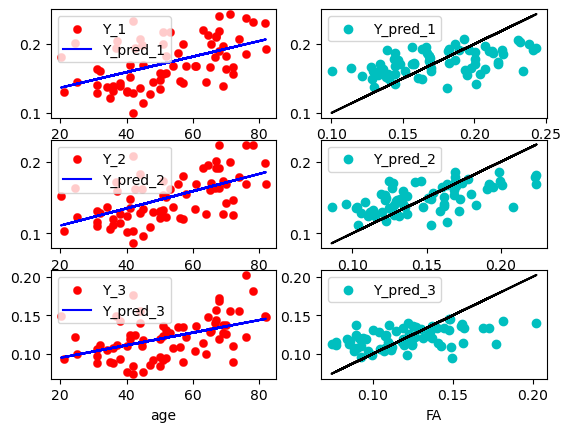

rh_BA1_exvivo
Weights:
[[0.00112452]] [[0.00112576]] [[0.00080395]]
MSE:
0.0007171117477021386 0.0004768215333140928 0.0004367496813293417
R2:
0.2984722452731404 0.390719581308994 0.26311002277473117


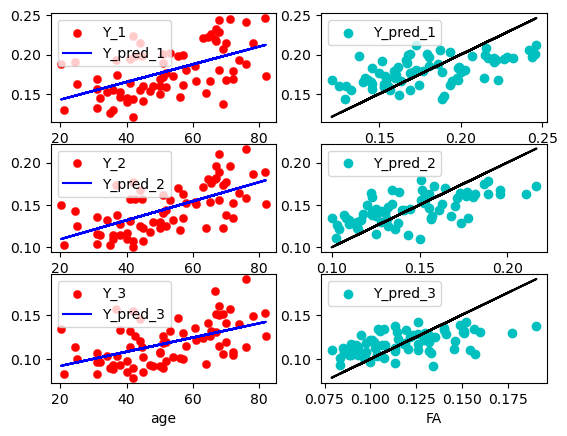

rh_BA2_exvivo_thresh
Weights:
[[0.00112008]] [[0.00115412]] [[0.0008324]]
MSE:
0.0011712253245480466 0.000630292998474857 0.0008068012328776276
R2:
0.20536972326847236 0.3376968768451064 0.17164365687944338


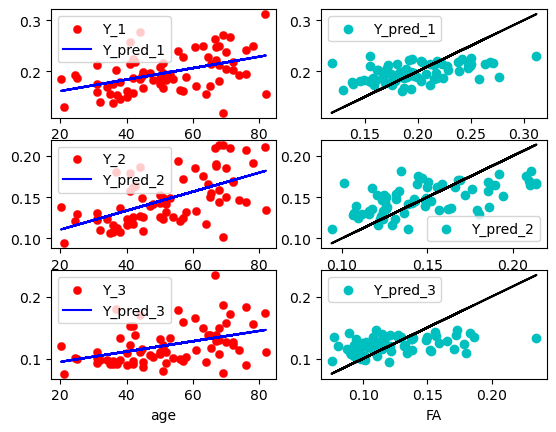

rh_BA2_exvivo
Weights:
[[0.00099631]] [[0.00103968]] [[0.00072438]]
MSE:
0.0007378419928521131 0.00046248373124165704 0.0004419685351350006
R2:
0.2450487455188073 0.3605817160527529 0.2226666936229197


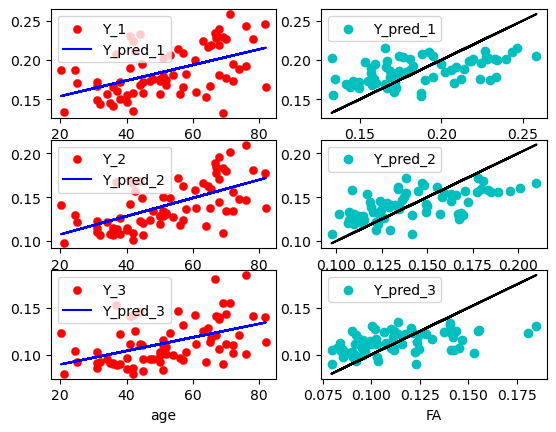

rh_BA3a_exvivo_thresh
Weights:
[[0.00095496]] [[0.00095988]] [[0.00059526]]
MSE:
0.0005215816461834759 0.0003961956947402076 0.0002656474052240125
R2:
0.29669145753927795 0.35942177698368727 0.24347258101052272


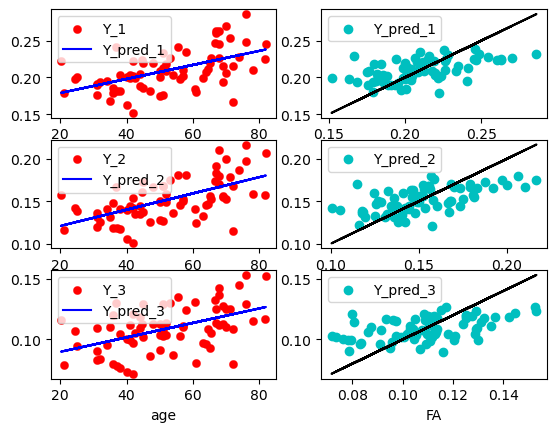

rh_BA3a_exvivo
Weights:
[[0.00102527]] [[0.0010026]] [[0.00061591]]
MSE:
0.0005536419354458874 0.00037036471190825325 0.0002611821019109714
R2:
0.31417401943285983 0.39571442738629903 0.25949513939020397


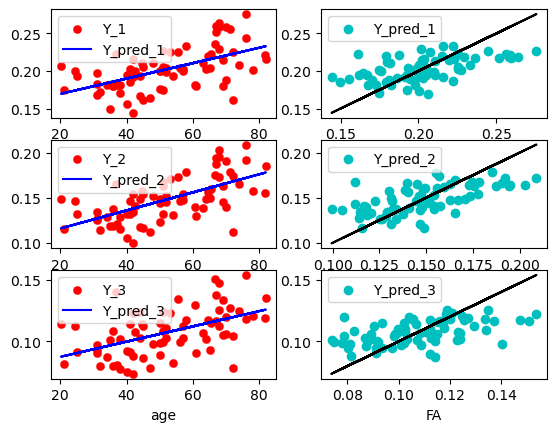

rh_BA3b_exvivo_thresh
Weights:
[[0.00138159]] [[0.00120802]] [[0.00068292]]
MSE:
0.0013811308338786907 0.0008677197817517117 0.00032927286665102354
R2:
0.2500678261318773 0.28864516003238083 0.25469855725345936


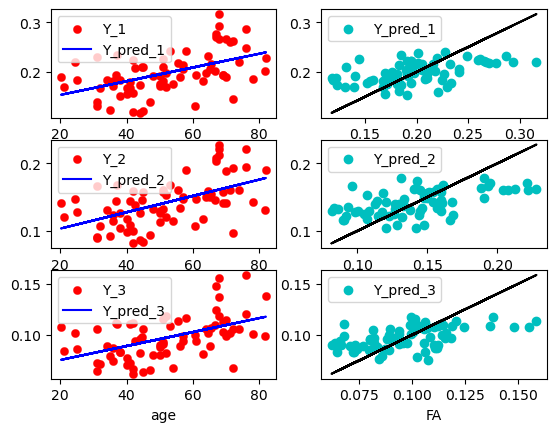

rh_BA3b_exvivo
Weights:
[[0.00122306]] [[0.00113328]] [[0.00071403]]
MSE:
0.0007865881980965215 0.0004895448946973316 0.0002876138590403889
R2:
0.3145245721174702 0.38762346317229224 0.2995719577014385


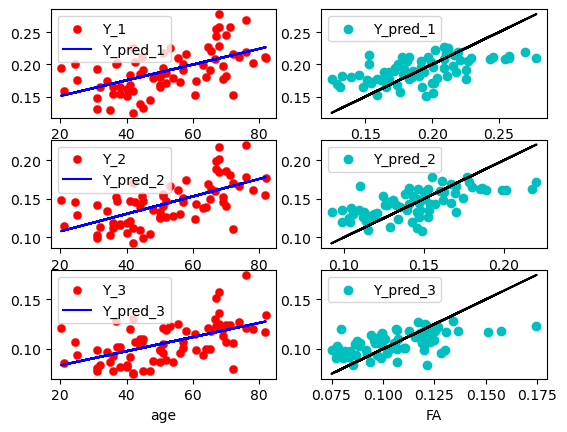

rh_BA4a_exvivo_thresh
Weights:
[[0.00084651]] [[0.00089157]] [[0.00059974]]
MSE:
0.0010067906831009638 0.0006702419643474655 0.0004062233156062638
R2:
0.14655939804433493 0.22248464907514331 0.17602922535864118


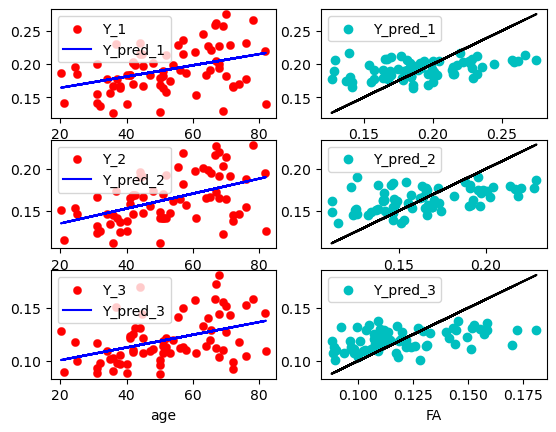

rh_BA4a_exvivo
Weights:
[[0.00099217]] [[0.00108077]] [[0.00070063]]
MSE:
0.0006982039755278992 0.0005187184415211121 0.0004902902884918158
R2:
0.25382974742634024 0.35204137954387327 0.19456565680555882


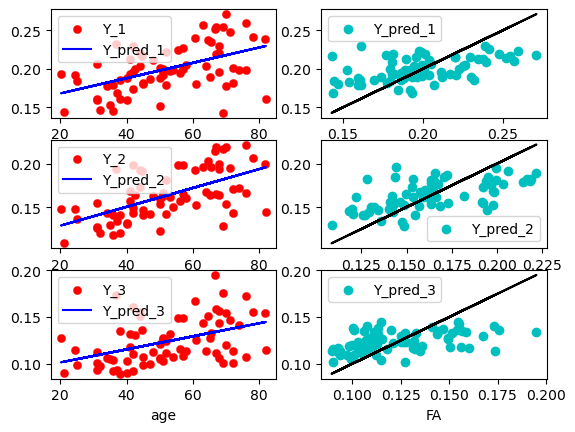

rh_BA4p_exvivo_thresh
Weights:
[[0.00083887]] [[0.00093899]] [[0.00058739]]
MSE:
0.0008142410990295342 0.0006083449678754367 0.0008977987639916765
R2:
0.1725400368858272 0.25909120584573786 0.08485503155501262


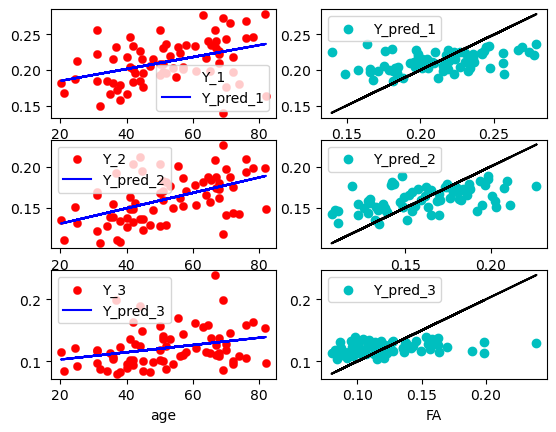

rh_BA4p_exvivo
Weights:
[[0.00092385]] [[0.00100032]] [[0.00062713]]
MSE:
0.000601506012138523 0.000417704361115165 0.0005323436941135382
R2:
0.2550412775013179 0.36628437521976853 0.15128626381753874


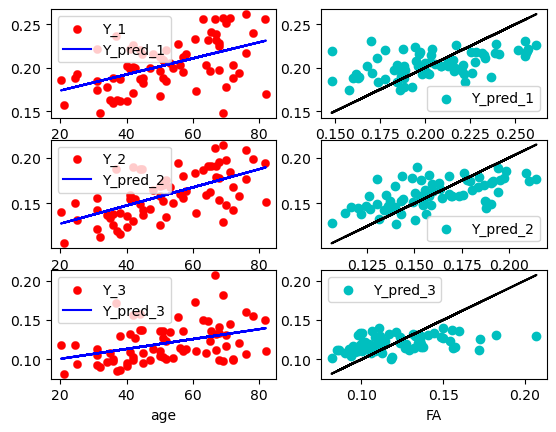

rh_BA6_exvivo_thresh
Weights:
[[0.00092357]] [[0.00108958]] [[0.00072658]]
MSE:
0.0005620896993272257 0.00047002441194896397 0.00043918181346349364
R2:
0.2680120166922645 0.37865296824585326 0.2248211391001903


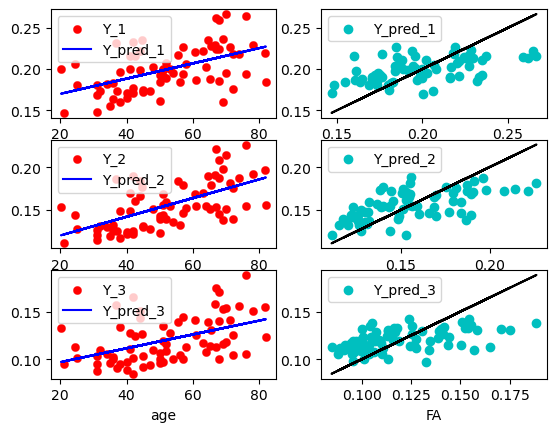

rh_BA6_exvivo
Weights:
[[0.00087496]] [[0.00098014]] [[0.00064889]]
MSE:
0.000556832109190006 0.0004428084563374429 0.00040213799856618433
R2:
0.24908752609512785 0.34359286650649534 0.2016752021271071


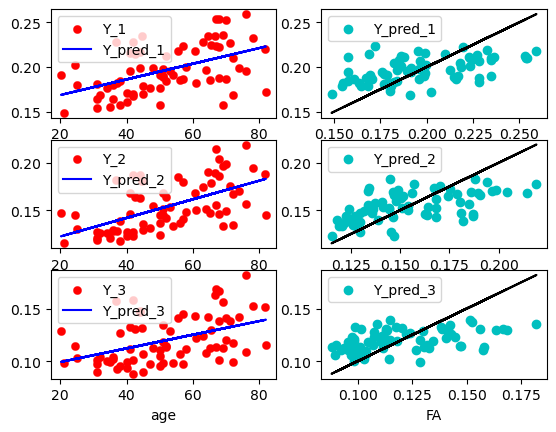

rh_BA44_exvivo_thresh
Weights:
[[0.00028785]] [[0.00054377]] [[0.0004419]]
MSE:
0.0007422247109962317 0.000551598958103786 0.000581556504355026
R2:
0.026228879193922028 0.11452520691829404 0.07494441673224983


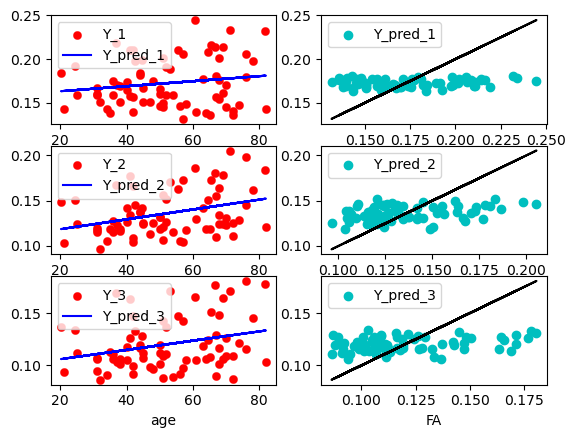

rh_BA44_exvivo
Weights:
[[0.00030483]] [[0.00055197]] [[0.0003974]]
MSE:
0.0004605702352122577 0.0003845969142482686 0.0003868857884443313
R2:
0.046417033530477436 0.16046469082288672 0.08965831546165215


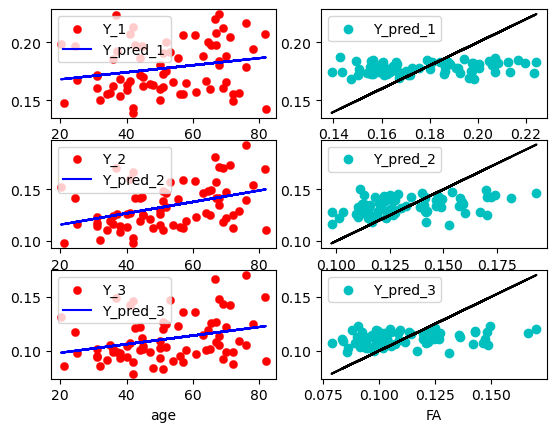

rh_BA45_exvivo_thresh
Weights:
[[0.00051683]] [[0.00069262]] [[0.00049296]]
MSE:
0.0009381654296546418 0.0006822258172177762 0.0005985460229290675
R2:
0.06427888783561175 0.14504850394401236 0.08921775528035913


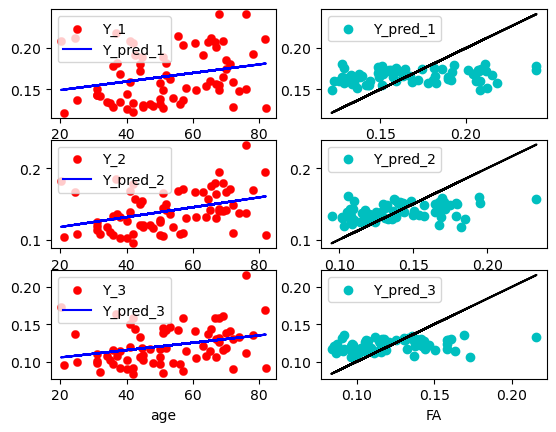

rh_BA45_exvivo
Weights:
[[0.00028676]] [[0.00055717]] [[0.00042474]]
MSE:
0.0005956044561995598 0.0004612124304377589 0.00046918909315158287
R2:
0.03223633687242189 0.13970927717860537 0.08489301990112719


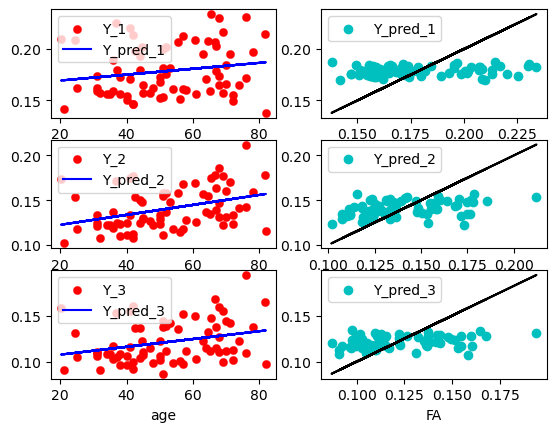

rh_cortex
Weights:
[[0.00040921]] [[0.00049875]] [[0.00029558]]
MSE:
0.0005196129272515827 0.00037121084229127375 0.00032732660712609155
R2:
0.0721459447509335 0.139176882667147 0.06050428599084379


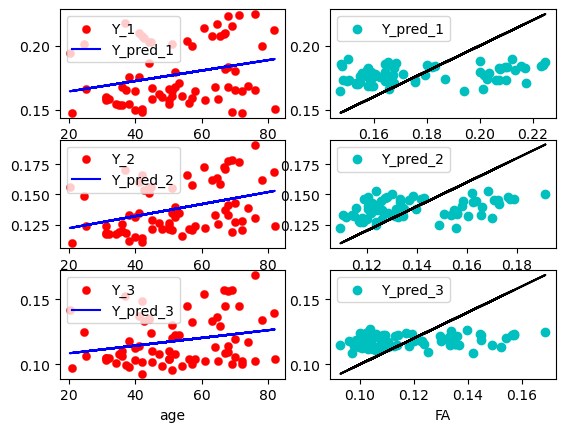

rh_cortex+hipamyg
Weights:
[[0.00039405]] [[0.00047785]] [[0.00027565]]
MSE:
0.0005197491874697892 0.0003735310022052085 0.0003300636683997645
R2:
0.06723388939429098 0.12853567891828888 0.05261903491150688


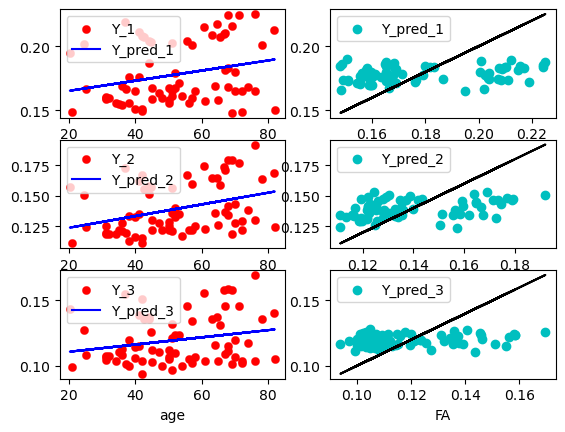

rh_entorhinal_exvivo_thresh
Weights:
[[-0.00021442]] [[-0.00039515]] [[-0.0004844]]
MSE:
0.0020104296989773653 0.0009934890409876275 0.0008624963133200066
R2:
0.005487561016973785 0.03653471388554341 0.061596720564419005


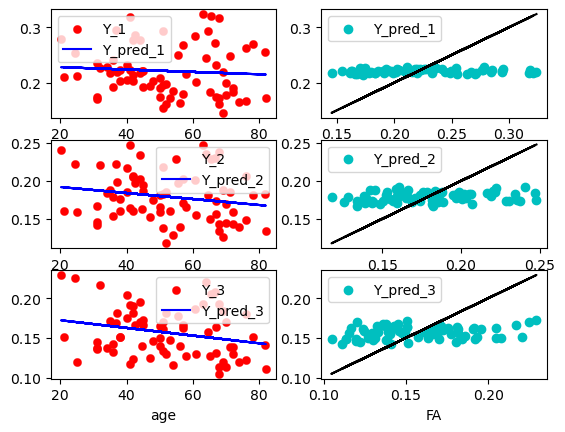

rh_entorhinal_exvivo
Weights:
[[-0.00016871]] [[-0.00033712]] [[-0.00041607]]
MSE:
0.0017968588918273788 0.0008927488145533373 0.0007263541549714125
R2:
0.0038072858603308557 0.029800209946224565 0.05437694398883819


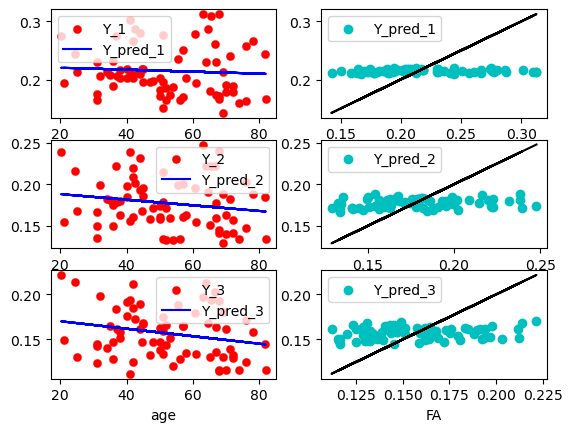

rh_FG1_mpm_vpnl
Weights:
[[4.45402215e-05]] [[0.00013189]] [[-7.38258646e-05]]
MSE:
0.0010445590004321914 0.0009121847774950854 0.0008699090388161044
R2:
0.00045802002354222715 0.004579818712551531 0.001509381027825718


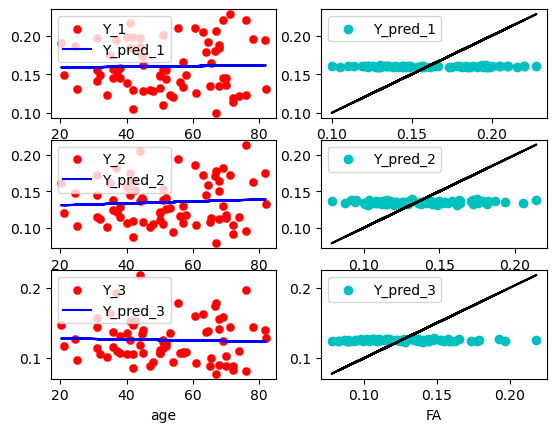

rh_FG2_mpm_vpnl
Weights:
[[5.95454867e-05]] [[0.00014958]] [[-1.81251116e-05]]
MSE:
0.001009836389335604 0.0008241302275190438 0.0008458578911413003
R2:
0.0008464290962172383 0.006508099870980555 9.369899582167829e-05


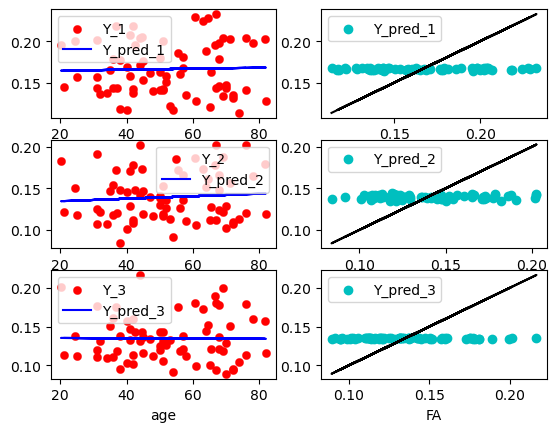

rh_FG3_mpm_vpnl
Weights:
[[0.00020359]] [[0.00023154]] [[2.22397174e-05]]
MSE:
0.0006848610496188945 0.000556066439577192 0.00046286409211445355
R2:
0.014392650248793104 0.022732624321896266 0.0002577536009048531


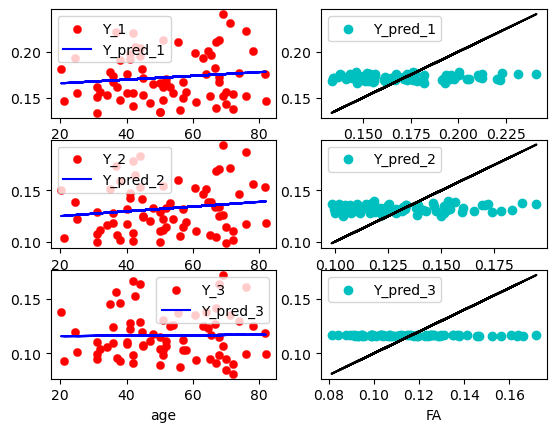

rh_FG4_mpm_vpnl
Weights:
[[-2.24833711e-05]] [[8.56387773e-05]] [[-8.39006073e-05]]
MSE:
0.0007612039338622507 0.0005951538393178048 0.0005113030224653827
R2:
0.0001602005165529663 0.00296438090864537 0.0033107263860565617


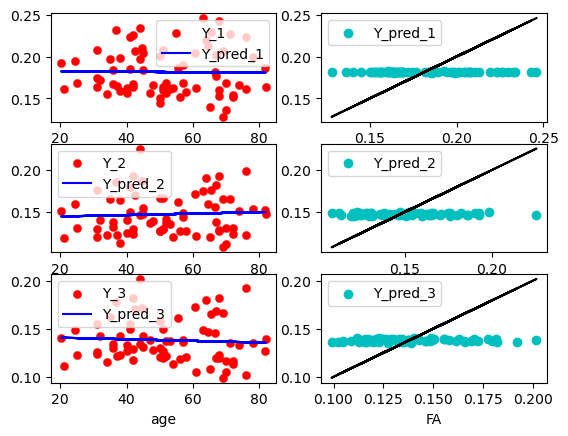

rh_hOc1_mpm_vpnl
Weights:
[[0.00047497]] [[0.00034429]] [[0.00011832]]
MSE:
0.000725617899040057 0.0005751509195364352 0.0005057428710352122
R2:
0.06977948032161663 0.047369886705800446 0.006634723235009465


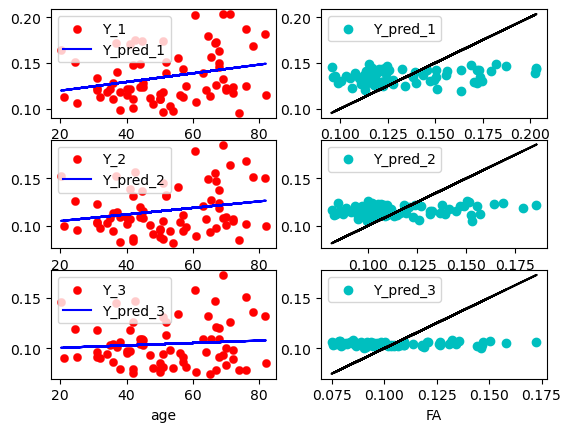

rh_hOc2_mpm_vpnl
Weights:
[[0.00045645]] [[0.00039055]] [[0.00013174]]
MSE:
0.0007281608307684498 0.00058561489580296 0.0004919968321611896
R2:
0.0645763215967915 0.05912812555967617 0.008439164979223146


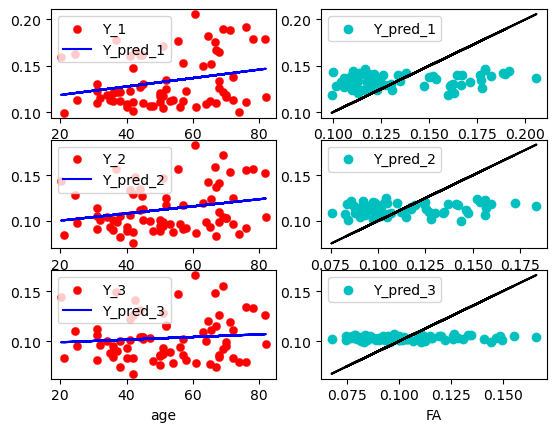

rh_hOc3v_mpm_vpnl
Weights:
[[0.00042544]] [[0.00037751]] [[0.00014099]]
MSE:
0.0007677167652267607 0.0006834987650124151 0.0008022688005028625
R2:
0.05382151651659306 0.047898416842594216 0.005942830435683111


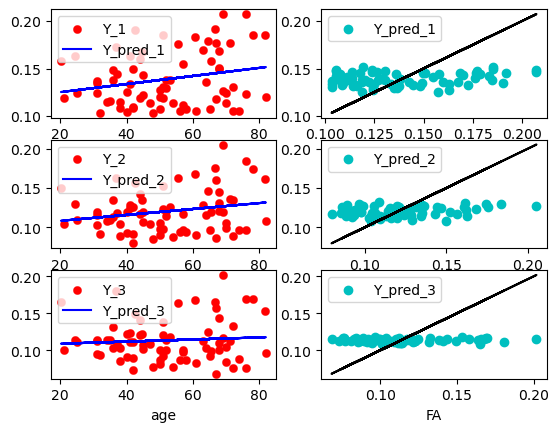

rh_hOc4v_mpm_vpnl
Weights:
[[0.00026397]] [[0.000257]] [[8.6145238e-05]]
MSE:
0.0009739599803776085 0.0008287417230077148 0.0009505633041195023
R2:
0.016968181025914464 0.018866981081007483 0.0018800780840837472


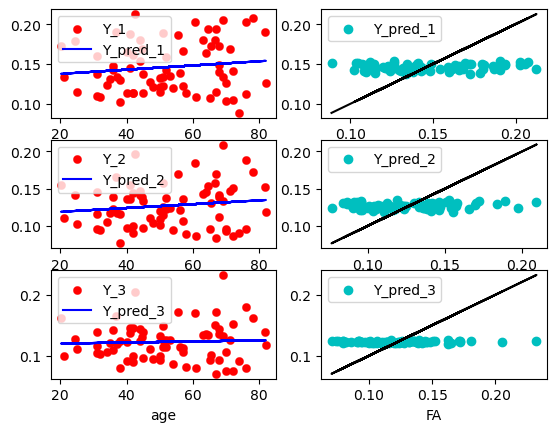

rh_MT_exvivo_thresh
Weights:
[[0.00044092]] [[0.00037325]] [[5.34255346e-05]]
MSE:
0.0011904197543571168 0.0007455149051437612 0.0005697151283147746
R2:
0.03791015144588972 0.04314147418302061 0.0012073328111422699


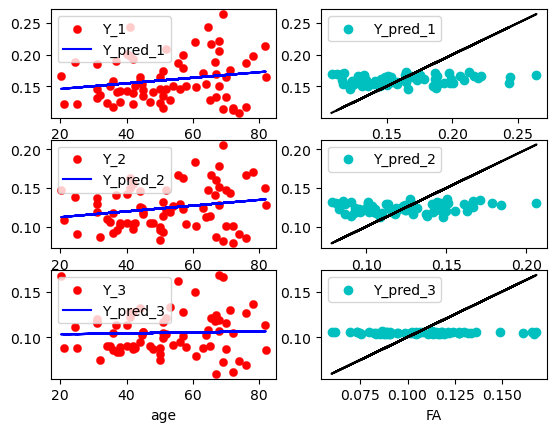

rh_MT_exvivo
Weights:
[[7.93144474e-05]] [[0.0002395]] [[0.00012099]]
MSE:
0.0007019246009813597 0.00043001938068723284 0.0003417536389216961
R2:
0.002157683379107156 0.031179390097546444 0.010228953215361769


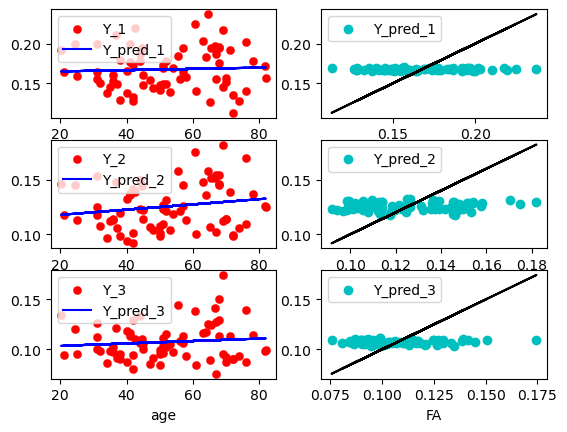

rh_nofix_cortex
Weights:
[[0.00036066]] [[0.000448]] [[0.00025836]]
MSE:
0.0005292735343342829 0.00038090967951273885 0.00033417690187865725
R2:
0.05597737453811458 0.11278873301859704 0.045976341139772225


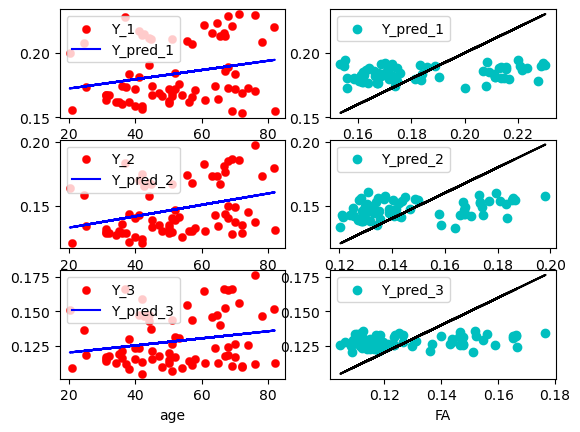

rh_perirhinal_exvivo_thresh
Weights:
[[-0.00014416]] [[-0.00025444]] [[-0.00031783]]
MSE:
0.0017755354653122125 0.0011677036965444055 0.0012367148838058981
R2:
0.0028160806452012244 0.013199682517786693 0.01932677509848324


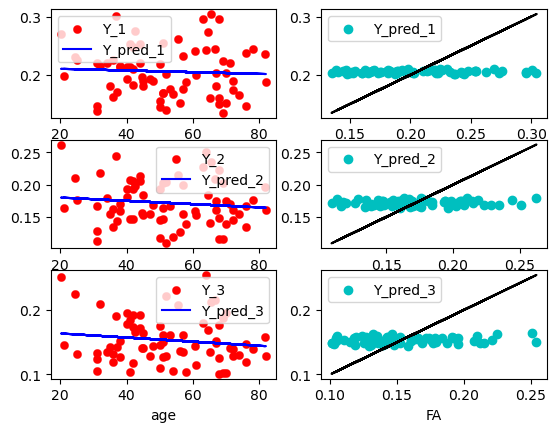

rh_perirhinal_exvivo
Weights:
[[-0.00020465]] [[-0.00028695]] [[-0.00034431]]
MSE:
0.0019468449480692382 0.0011553813224371545 0.0009115116060852594
R2:
0.005163396756490579 0.016904285002409813 0.030425055591461136


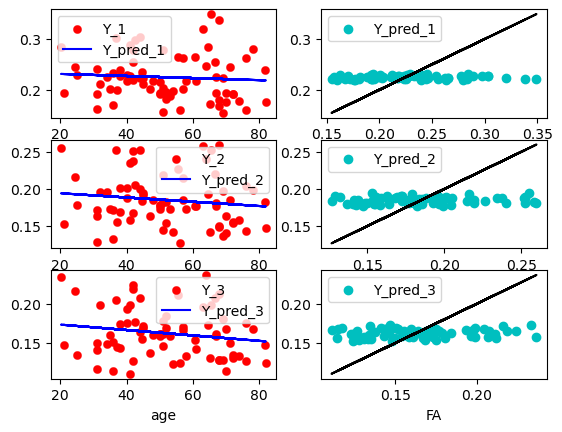

rh_V1_exvivo_thresh
Weights:
[[0.00047269]] [[0.000347]] [[0.00012576]]
MSE:
0.0007462679297582335 0.0005986392399064913 0.0005350411746138676
R2:
0.06737276699999817 0.04628229325389688 0.007081517404519899


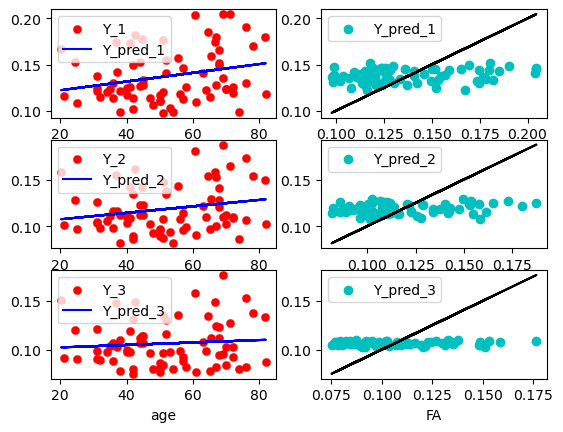

rh_V1_exvivo
Weights:
[[0.00047868]] [[0.00034296]] [[0.00010012]]
MSE:
0.0007395845401615112 0.000624269807894262 0.0005702768790753294
R2:
0.06955224689109385 0.043483654932415905 0.004222799951533296


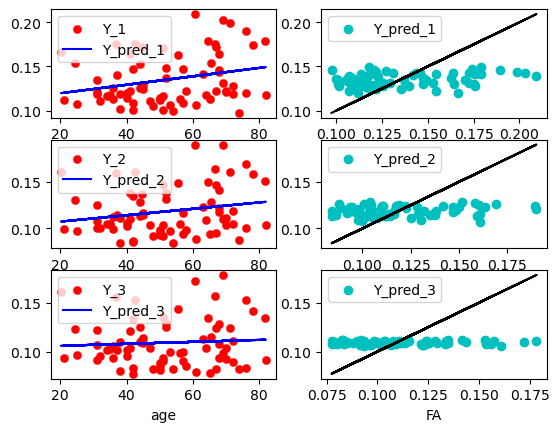

rh_V2_exvivo_thresh
Weights:
[[0.00043886]] [[0.00034517]] [[8.92648816e-05]]
MSE:
0.0007343567239665462 0.0006145836711803317 0.0005511368527155782
R2:
0.059513758613013557 0.04468376440308397 0.003476171221047486


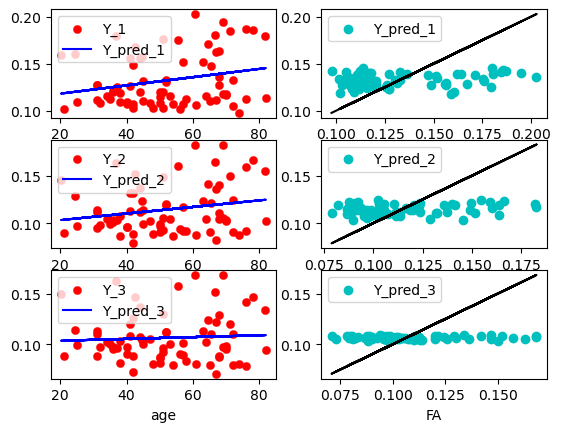

rh_V2_exvivo
Weights:
[[0.0003904]] [[0.00033435]] [[8.11168785e-05]]
MSE:
0.0006912830900184234 0.000557878763844126 0.0005088910249518572
R2:
0.05050771877228466 0.046118354110145865 0.0031099727029605395


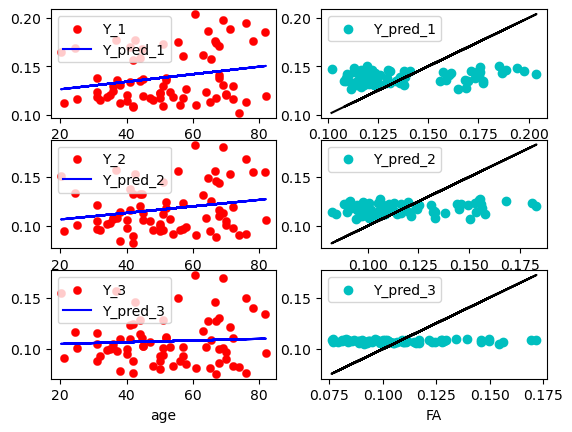

In [42]:
# For left hemisphere
for region in region_list:
    print('rh_' + region)
    Y_1 = right_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = right_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = right_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    print('Weights:')
    print(weights_1, weights_2, weights_3)
    print('MSE:')
    print(mse_1, mse_2, mse_3)
    print('R2:')
    print(r2_1, r2_2, r2_3)
    plt.subplot(3, 2, 1)
    plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 2)
    plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
    plt.plot(Y_1[:,0], Y_1[:,0], color='k')
    plt.legend()
    plt.xlabel('FA')
    plt.subplot(3, 2, 3)
    plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 4)
    plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
    plt.plot(Y_2[:,0], Y_2[:,0], color='k')
    plt.legend()
    plt.xlabel('FA')
    plt.subplot(3, 2, 5)
    plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 6)
    plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
    plt.plot(Y_3[:,0], Y_3[:,0], color='k')
    plt.legend()
    plt.xlabel('FA')

    plt.show()
